# Ingeniería de variables

**Trabajo Fin de Máster · Big Data y Data Science**
Predicción del precio horario del mercado diario español y optimización de un sistema de
almacenamiento

---

Este cuaderno **construye y trata**. Toma la capa bronce y las conclusiones de
`01_analisis_exploratorio.ipynb` y entrega la matriz sobre la que se entrenan los modelos.

No descubre nada nuevo sobre el dato: cada corrección que aplica y cada variable que deriva
responde a un hallazgo ya demostrado en el cuaderno anterior, que se cita por su código.

## Las tres reglas que gobiernan el cuaderno

**Primera: la partición va delante.** El apartado 0 separa entrenamiento, validación y prueba
antes de tocar nada. A partir de ahí, toda decisión —qué umbral de atípico, qué valor de
imputación, qué transformación, qué variable sobrevive al cribado— se toma mirando **únicamente
`train`**. Es la diferencia práctica entre este cuaderno y el exploratorio: aquél describía y
podía mirarlo todo; éste decide, y decidir mirando la validación infla el resultado que se
publique después.

**Segunda: la frontera de disponibilidad es un filtro, no un comentario.** Una columna entra a la
matriz si estaba disponible a las 12:00 del día D, o no entra. La tabla vive en `comun_tfm.py` y
es la misma que el cuaderno exploratorio usa para colorear sus figuras.

**Tercera: nada entra sin quedar registrado.** El apartado 8 publica el registro de decisiones, y
ese registro se construye solo, a partir de las anotaciones que cada apartado deja al ejecutarse.
Lo que no está en la tabla, no está en la matriz.

## La alineación temporal, que es el corazón del asunto

Una fila de la matriz es **(día objetivo, hora)**, y el día objetivo es D+1. La predicción se
emite a las **12:00 del día D**, cuando se celebra la casación del mercado diario. En ese
instante:

| Familia | Lo último disponible | Desfase respecto al día objetivo |
|---|---|---|
| Previsiones de REE para D+1 | el propio D+1 | **0** — se usan tal cual |
| Curva de precios ya casada | el día D completo | **−1 día** |
| Generación, demanda, meteorología reales | el día D−1 completo (de D sólo han pasado 00-11) | **−2 días** |
| Cierres de commodities | el de D−1 (cierran ~17:30, tras el cierre eléctrico) | **−2 días** |

Las dos últimas filas coinciden en el mismo desfase, y eso resuelve la aparente contradicción de
la etiqueta `DESFASE D-2` de la frontera: está expresada respecto al **día objetivo**, no respecto
al día de predicción. El sufijo `_Dm1` que emplea el resto del proyecto nombra la misma magnitud
—el día anterior al de predicción— y se conserva aquí por compatibilidad.

## Estructura

| Bloque | Contenido | Correspondencia en el máster |
|---|---|---|
| **0** | Partición temporal y validez de los procedimientos | `train_test_split` de `VinoSelecVar` |
| **1** | La frontera como filtro de admisión | — (propio del problema) |
| **2** | Correcciones heredadas del EDA | «Missings no declarados / fuera de rango» de `VinoDep` |
| **3** | Atípicos, perdidos e imputación | `atipicosAmissing`, `patron_perdidos`, `ImputacionCuant` |
| **4** | Construcción de variables | Transformaciones e interacciones |
| **5** | Los dos objetivos | `varObjCont` y `varObjBin` |
| **6** | Depuración de la matriz | Constantes y redundancia |
| **7** | Importancia y preselección | `Vcramer`, `graficoVcramer` |
| **8** | Matriz final y registro de decisiones | Guardado del `pickle` depurado |

---
# 0 · Partición temporal y validez de los procedimientos

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd()))
import comun_tfm as cm
from comun_tfm import (PALETA, COLOR_FUGA, DIAS, TZ, K_HORAS, FRONTERA, ADMISIBLES,
                       fuga_de, v_cramer, clasificar_horas, Registro)

# Las funciones canónicas del máster, tal como se vendaron en el repositorio.
sys.path.insert(0, str(cm.RAIZ / "scripts"))
from funciones_mineria import atipicosAmissing, patron_perdidos, ImputacionCuant, mejorTransfCorr

%matplotlib inline
cm.configurar_matplotlib()

DEC = Registro("REGISTRO DE DECISIONES")
print("Funciones del máster importadas de scripts/funciones_mineria.py")

Funciones del máster importadas de scripts/funciones_mineria.py


In [2]:
df = cm.cargar_bronce()
COLS = cm.resolver_columnas(df)
globals().update(COLS)
DRIVERS = cm.drivers_de(df, COLS)

print(f"Bronce: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Objetivo: {P}")

Bronce: 58,319 filas × 104 columnas
Objetivo: spot_es_esios


## 0.1 · La partición

La partición es **temporal y sin barajar**. Un `train_test_split` aleatorio como el del máster
—apropiado para observaciones independientes— colocaría aquí horas del mismo día a ambos lados
del corte, y con retardos de 24 y 168 horas entre las variables eso es fuga directa.

Los cortes son los que ya emplea el resto del proyecto, para que los resultados de este cuaderno
sean comparables con los de la cadena de modelado existente.

In [3]:
CORTE_VALID = pd.Timestamp("2025-01-02", tz=TZ)
CORTE_TEST  = pd.Timestamp("2026-01-02", tz=TZ)

def marcar_split(ts_local: pd.Series) -> pd.Series:
    return pd.Series(np.select([ts_local < CORTE_VALID, ts_local < CORTE_TEST],
                               ["train", "validation"], default="test"),
                     index=ts_local.index)

df["split"] = marcar_split(df["ts_local"])
resumen = df.groupby("split", sort=False).agg(
    horas=("ts_utc", "size"), desde=("ts_local", "min"), hasta=("ts_local", "max"))
display(resumen.loc[["train", "validation", "test"]])

TRAIN = df["split"] == "train"
print(f"\nA partir de aquí, toda decisión se toma sobre las {TRAIN.sum():,} horas de train.")

,horas,desde,hasta
split,,,
train,43872,2020-01-01 00:00:00+01:00,2025-01-01 23:00:00+01:00
validation,8760,2025-01-02 00:00:00+01:00,2026-01-01 23:00:00+01:00
test,5687,2026-01-02 00:00:00+01:00,2026-08-26 23:00:00+02:00



A partir de aquí, toda decisión se toma sobre las 43,872 horas de train.


## 0.2 · Los procedimientos y su validez sobre una serie temporal

La ingeniería de variables no se aborda aquí desde una receta única, porque el programa del
máster contiene **dos**, formuladas para problemas distintos, y este trabajo se sitúa entre las
dos:

| Procedencia | Qué prescribe | Para qué tipo de dato |
|---|---|---|
| *Minería de Datos*, día 1 — preparación (`VinoDep.py`) | Tipado, descriptivos, missings no declarados, valores fuera de rango, atípicos a ausente, imputación | Datos **transversales**: una fila por individuo, sin orden entre ellas |
| *Minería de Datos*, día 4 — transformaciones y selección (`VinoSelecVar_*.py`) | Agrupar categorías, transformar continuas para linealizar, cribado previo por correlación y V de Cramér, selección *forward* / *backward* / *stepwise* por AIC o BIC | Ídem |
| *Machine Learning* — preprocesado (`1_empezamos_ML.ipynb`) | `ColumnTransformer` con `StandardScaler` y `OneHotEncoder`, ajustado sobre entrenamiento | Ídem, con validación cruzada |
| *Redes recurrentes* — «Feature Engineering» (`Introduction_to_RNN_Time_Series.ipynb`) | Corregir centinelas imposibles, reexpresar variables en la forma que el modelo puede aprovechar, **codificación cíclica del tiempo en seno y coseno**, **partición temporal sin barajar**, normalización adaptada **sólo al tramo de entrenamiento** | **Series temporales** |

El dato de este trabajo es una serie horaria. Donde las dos familias de procedimientos divergen,
se sigue la segunda, y este apartado deja constancia de dónde ocurre eso y por qué. La razón de
documentarlo es que varias funciones de `FuncionesMineria.py` **producen resultados incorrectos**
sobre datos ordenados en el tiempo, y aplicarlas sin advertirlo daría cifras mejores y
conclusiones peores.

### Lo que se adopta del enfoque transversal

**El cribado previo por asociación** (día 4). Las diapositivas lo recomiendan «de cara a detectar
variables que realmente no aportan nada», con la cautela expresa de emplearlo «únicamente cuando
estemos trabajando con muchas variables y/o el no efecto de las variables sea muy evidente».
Ambas condiciones se cumplen aquí, y el apartado 7 lo aplica en ese espíritu: como criba, no como
selección, exigiendo que una variable falle **los dos** estadísticos —Pearson y V de Cramér—
antes de retirarla.

**Conservar la variable original junto a la transformada.** El mismo material advierte de que «en
ocasiones puede ocurrir que la variable independiente aporte información en su forma original y
transformada, por lo que se mantienen ambas en el modelo». Es lo que hace el apartado 4.8.

**El diagnóstico de atípicos y el patrón de valores ausentes** (día 1), que se ejecutan tal cual
en los apartados 3.1 y 3.2.

### Lo que se toma del enfoque de series temporales

**La partición sin barajar** del apartado 0.1, **la codificación cíclica del tiempo** del
apartado 4.6 —seno y coseno de la hora, del día de la semana y del mes, exactamente la
construcción `Day sin` / `Day cos` / `Year sin` / `Year cos` del material de redes recurrentes— y
**el ajuste de todo parámetro sobre `train` únicamente**, que es lo que allí hace `norm.adapt()`
sobre el conjunto de entrenamiento y aquí gobierna la corrección de sesgo, la imputación y la
normalización de las transformaciones.

También la corrección de **centinelas físicamente imposibles**: donde aquel material sustituye
una velocidad de viento de −9999 m/s, el apartado 2.1 repara una demanda peninsular de 0 MW.

### Los cuatro procedimientos que no se aplican, y qué se hace en su lugar

**`atipicosAmissing` — convertiría el objetivo en ruido.** Marca como atípico el valor que supera
tres desviaciones típicas —u ocho MAD si la distribución es asimétrica— y además cae fuera del
rango intercuartílico ampliado, y lo sustituye por un valor ausente. En el precio eléctrico los
valores extremos **son la señal**: las horas de precio disparado dominan el error de cualquier
estimación y las de precio negativo son las que dan valor al arbitraje de la batería. El
apartado 3.3 del análisis exploratorio cuantificó su peso —pocas en porcentaje, decisivas en
euros—. Se añade un segundo motivo: el criterio intercuartílico supone una distribución estable,
y aquí hay cambios estructurales reales que la función marcaría como miles de atípicos.
*En su lugar:* detectar lo **físicamente imposible** con criterio de dominio, que es lo que hizo
el bloque 2 del análisis exploratorio. Los extremos estadísticos se documentan; no se borran.

**`ImputacionCuant` — una media global sobre una serie con tendencia.** Imputar la generación
solar de una hora nocturna con la media anual introduce un valor imposible; y con la potencia
fotovoltaica instalada multiplicándose por seis en el período, la media global no representa
ningún momento concreto de la serie.
*En su lugar:* interpolación temporal con límite de horas (apartado 3.4), y criterio por
variable: las de pico no se interpolan linealmente, porque hacerlo subestima los eventos
extremos, que son los que mueven el precio.

**`validacion_cruzada_lm` y `validacion_cruzada_glm` — fuga temporal garantizada.** Emplean
`KFold` con partición aleatoria, que sobre una serie temporal coloca horas del futuro en
entrenamiento y horas del pasado en validación. Con la autocorrelación medida en el apartado 3.6
del análisis exploratorio, el modelo tendría casi siempre una hora contigua en entrenamiento y
aprendería a **interpolar** en lugar de a predecir.
*En su lugar:* la partición estrictamente temporal del apartado 0.1.

**`lm_stepwise` y `glm_stepwise` — selección sobre observaciones no independientes.** La selección
paso a paso por AIC o BIC supone independencia entre observaciones. Con autocorrelación, el
número efectivo de observaciones es muy inferior al nominal, los criterios de información quedan
sesgados y el procedimiento tiende a incorporar variables de más.
*En su lugar:* selección validada temporalmente o mediante regularización, midiendo la aportación
de cada variable sobre el tramo de validación, y siempre después de aplicar la frontera de
disponibilidad. Cabe señalar que el propio material del día 4 apunta en esa dirección al proponer
la **selección aleatoria sobre submuestras repetidas**, cuya lógica —quedarse con lo que se
repite— es la que aquí adopta la verificación fuera de muestra.

### El caso intermedio: `mejorTransfCorr` y `Transf_Auto`

Prueban siete transformaciones y conservan la que maximiza la correlación con el objetivo. El
riesgo es de sobreajuste: elegir mirando el objetivo incorpora a la elección el ruido de la
muestra, y sobre decenas de miles de observaciones **algo siempre mejora**.

No se descartan, pero **no se usan tal cual**: la búsqueda se realiza sólo sobre `train` y la
ganancia se verifica después en `validation`, conservando únicamente las transformaciones cuya
mejora persiste. El apartado 4.8 documenta el resultado de esa verificación. Y cuando existe una
razón física se prefiere a la búsqueda automática: la relación entre demanda y temperatura no
necesita explorar siete funciones, necesita grados-día, que es la transformación que la
ingeniería del sector emplea y que además es interpretable.

In [4]:
VALIDEZ = pd.DataFrame([
    ("analizar_variables_categoricas", "Minería · día 1", "se adopta", "Descriptivo puro"),
    ("cuentaDistintos", "Minería · día 1", "se adopta",
     "Equivale al barrido de columnas constantes del apartado 2.3"),
    ("frec_variables_num", "Minería · día 1", "se adopta", "Descriptivo puro"),
    ("patron_perdidos", "Minería · día 1", "se adopta con salvedad",
     "Aquí la mayoría de ausencias son estructurales, no aleatorias (apartado 3.2)"),
    ("atipicosAmissing", "Minería · día 1", "NO se aplica",
     "El valor extremo es la señal, no un error de medida"),
    ("ImputacionCuant", "Minería · día 1", "NO se aplica",
     "Media global sobre una serie con tendencia; se interpola en el tiempo"),
    ("Vcramer / graficoVcramer", "Minería · día 4", "se adopta con salvedad",
     "Sobre el marco de frecuencia adecuada (apartado 4.0 del análisis exploratorio)"),
    ("mejorTransfCorr / Transf_Auto", "Minería · día 4", "sólo con verificación",
     "Buscar en train y verificar en validación (apartado 4.8)"),
    ("lm_stepwise / glm_stepwise", "Minería · día 4", "NO se aplica",
     "Supone independencia entre observaciones"),
    ("validacion_cruzada_lm / _glm", "Minería · día 4", "NO se aplica",
     "KFold aleatorio sobre una serie temporal es fuga"),
    ("Partición temporal sin barajar", "Redes recurrentes", "se adopta",
     "Apartado 0.1"),
    ("Codificación cíclica en seno y coseno", "Redes recurrentes", "se adopta",
     "Apartado 4.6"),
    ("Parámetros ajustados sólo en train", "Redes recurrentes / ML", "se adopta",
     "Sesgo, imputación y normalización de las transformaciones"),
    ("Corrección de centinelas imposibles", "Redes recurrentes", "se adopta",
     "Apartado 2.1: la demanda de 0 MW"),
], columns=["procedimiento", "procedencia", "veredicto", "motivo"])
display(VALIDEZ.set_index("procedimiento"))

print(f"Se adoptan {(VALIDEZ['veredicto'].str.startswith('se adopta')).sum()} procedimientos, "
      f"{(VALIDEZ['veredicto'] == 'NO se aplica').sum()} se descartan de forma razonada y "
      f"{(VALIDEZ['veredicto'] == 'sólo con verificación').sum()} se emplea bajo control.")

,procedencia,veredicto,motivo
procedimiento,,,
analizar_variables_categoricas,Minería · día 1,se adopta,Descriptivo puro
cuentaDistintos,Minería · día 1,se adopta,Equivale al barrido de columnas constantes del...
frec_variables_num,Minería · día 1,se adopta,Descriptivo puro
patron_perdidos,Minería · día 1,se adopta con salvedad,Aquí la mayoría de ausencias son estructurales...
atipicosAmissing,Minería · día 1,NO se aplica,"El valor extremo es la señal, no un error de m..."
ImputacionCuant,Minería · día 1,NO se aplica,Media global sobre una serie con tendencia; se...
Vcramer / graficoVcramer,Minería · día 4,se adopta con salvedad,Sobre el marco de frecuencia adecuada (apartad...
mejorTransfCorr / Transf_Auto,Minería · día 4,sólo con verificación,Buscar en train y verificar en validación (apa...
lm_stepwise / glm_stepwise,Minería · día 4,NO se aplica,Supone independencia entre observaciones


Se adoptan 9 procedimientos, 4 se descartan de forma razonada y 1 se emplea bajo control.


---
# 1 · La frontera de disponibilidad como filtro de admisión

El cuaderno exploratorio usó esta tabla para **colorear**. Aquí se usa para **filtrar**: se
recorre el bronce columna a columna, se le asigna su veredicto y se retiene únicamente lo
admisible.

Es una poda severa y conviene verla cuantificada, porque el coste de la restricción operativa es
uno de los resultados del trabajo.

In [5]:
FRONTERA

,tabla,veredicto,motivo
0,spot_price (España),TARGET,"Casación a las 12:00 de D, publicación ~12:45"
1,spot_price (11 zonas),CON FUGA,Casación SDAC simultánea: el de D+1 no existe ...
2,forecast (REE),SIN FUGA,Publicada antes de las 11:00 de D-1 (Circular ...
3,entsoe_forecast_da,SIN FUGA*,Se reescribe hacia atrás: ver bloque 2.6 del EDA
4,ecmwf_forecast_agg,SIN FUGA*,Sin histórico: ventana móvil de días. Ver bloq...
5,esios_capacity_available,CONDICIONAL,D-01: el valor guardado conoce el propio día
6,era5_weather_agg,CON FUGA,"Reanálisis: el tiempo que ocurrió, no el previsto"
7,generation / load_inter,CON FUGA,Real: a las 12:00 sólo han pasado las horas 00-11
8,esios_pdbc_gen,CON FUGA,Misma casación que el precio: circular
9,commodities / trayport,DESFASE D-2,"Cierran ~17:30, tras el cierre eléctrico"


In [6]:
CONTROL = ["ts_utc", "ts_local", "date_utc", "date_local", "hour_utc", "hour_local",
           "hora", "dia", "anio", "mes", "dow", "mes_p", "regimen", "split"]

numericas_bronce = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in CONTROL and c != "tensor_index"]

veredicto = pd.Series({c: fuga_de(c, P) for c in numericas_bronce}, name="veredicto")
reparto = veredicto.value_counts().rename("columnas del bronce").to_frame()
reparto["admisible"] = [v in ADMISIBLES for v in reparto.index]
display(reparto)

admisibles_directas = sorted(veredicto[veredicto.isin(ADMISIBLES)].index)
con_fuga = sorted(veredicto[veredicto == "CON FUGA"].index)

print(f"\nAdmisibles tal cual        : {len(admisibles_directas):3d} columnas")
print(f"Con fuga (sólo retardadas) : {len(con_fuga):3d} columnas")
print(f"Condicionales (excluidas)  : {(veredicto == 'CONDICIONAL').sum():3d} columnas")

DEC.anotar("A.1", "Frontera de disponibilidad aplicada como filtro", "aplicado",
           f"{len(admisibles_directas)} columnas admitidas sin retardo, {len(con_fuga)} sólo "
           f"con retardo de dos días, {(veredicto == 'CONDICIONAL').sum()} excluidas por "
           "no poder verificarse el instante de conocimiento (D-01).")

,columnas del bronce,admisible
veredicto,,
CON FUGA,59,False
SIN FUGA,22,True
CONDICIONAL,6,False
DESFASE D-2,3,True
TARGET,1,False



Admisibles tal cual        :  25 columnas
Con fuga (sólo retardadas) :  59 columnas
Condicionales (excluidas)  :   6 columnas
  [A.1] aplicado: Frontera de disponibilidad aplicada como filtro


---
# 2 · Correcciones heredadas del análisis exploratorio

Cada corrección de este apartado cita el hallazgo que la justifica. Ninguna es una decisión nueva:
son la ejecución de lo que el cuaderno anterior demostró.

Se corresponde con el tramo de `VinoDep.py` que va desde «Missings no declarados» hasta «Errores
de escritura», con la diferencia de que aquí cada línea tiene detrás una comprobación empírica en
lugar de una inspección visual.

## 2.1 · Los nueve ceros espurios de demanda *(C.1)*

In [7]:
DEM_ALT = cm.pick(df, "load_inter_ree_load")
n_ceros = int((df[DEM] == 0).sum())
if n_ceros and DEM_ALT:
    mal = df[DEM] == 0
    reparables = mal & df[DEM_ALT].gt(0)
    df.loc[reparables, DEM] = df.loc[reparables, DEM_ALT]
    df.loc[mal & ~reparables, DEM] = np.nan       # sin segunda fuente: a perdido, no a cero
    print(f"{n_ceros} ceros detectados · {int(reparables.sum())} reparados con {DEM_ALT} · "
          f"{int((mal & ~reparables).sum())} marcados como perdidos")
    print(f"Demanda mínima tras la reparación: {df[DEM].min():,.0f} MW")
    DEC.anotar("C.1", "Ceros espurios de demanda reparados con la segunda fuente", "aplicado",
               "Reparar con un segundo camino de ingesta conserva el dato real; imputar lo "
               "habría inventado. Los no reparables quedan como perdidos declarados.")
else:
    print("Sin ceros espurios en esta versión del bronce.")

9 ceros detectados · 9 reparados con load_inter_ree_load · 0 marcados como perdidos
Demanda mínima tras la reparación: 6,549 MW
  [C.1] aplicado: Ceros espurios de demanda reparados con la segunda fuente


## 2.2 · La convención asimétrica del bombeo *(B.1)*

In [8]:
if PG:
    antes = df[PG].isna().sum()
    # NaN en turbinación significa "no hubo turbinación", no "se desconoce". Sin este paso,
    # cualquier .agg(["mean","min","max"]) posterior ignora los NaN e infla la media diaria.
    media_antes = df[PG].mean()
    df[PG] = df[PG].fillna(0)
    print(f"{antes:,} nulos convertidos en ceros explícitos")
    print(f"Media horaria de turbinación: {media_antes:,.1f} MW (ignorando nulos) → "
          f"{df[PG].mean():,.1f} MW (contándolos como cero)")
    DEC.anotar("B.1", "fillna(0) sobre la turbinación antes de cualquier agregación", "aplicado",
               "Sólo sobre esta columna: en el resto del conjunto un NaN sí significa que el "
               "valor se desconoce.")

25,571 nulos convertidos en ceros explícitos
Media horaria de turbinación: 951.9 MW (ignorando nulos) → 534.5 MW (contándolos como cero)
  [B.1] aplicado: fillna(0) sobre la turbinación antes de cualquier agregación


## 2.3 · Columnas descartadas por lo que el EDA demostró

In [9]:
# El criterio es el coeficiente de variacion, no el recuento de valores distintos: el apartado
# 1.5 del analisis exploratorio mostro que dos columnas con 23 y 48 valores distintos varian
# menos del 0,05 % de su media y son constantes a efectos practicos.
UMBRAL_CV = 5.0

# El CV solo tiene sentido en escalas de RAZON, donde el cero significa "nada": megavatios,
# energia, capacidad. No lo tiene en escalas de intervalo con origen arbitrario -- la
# temperatura en kelvin o la presion en pascales dan un CV diminuto por el desplazamiento del
# origen, no por falta de variacion. Por eso la prueba se restringe a la familia de capacidad,
# que es donde el apartado 1.5 del analisis exploratorio la motivo.
ESCALA_DE_RAZON = ("cap_inst_", "cap_disp_")

cv = pd.Series({c: (df.loc[TRAIN, c].std() / abs(df.loc[TRAIN, c].mean()) * 100
                    if df.loc[TRAIN, c].notna().any() and df.loc[TRAIN, c].mean() != 0 else np.nan)
                for c in numericas_bronce if c.startswith(ESCALA_DE_RAZON)})
exactas = [c for c in numericas_bronce
           if df.loc[TRAIN, c].notna().any() and df.loc[TRAIN, c].nunique(dropna=True) <= 1]
cuasi = [c for c in cv[cv < UMBRAL_CV].index if c not in exactas]
constantes = sorted(set(exactas) | set(cuasi))

print(f"Constantes exactas en train : {len(exactas):2d}")
print(f"Cuasi-constantes (CV < {UMBRAL_CV} %) : {len(cuasi):2d}")
if cuasi:
    print("\nLas que un filtro por valores distintos habría dejado pasar:")
    for c in sorted(cuasi, key=lambda x: cv[x]):
        print(f"  {c:38s} {df.loc[TRAIN, c].nunique():3d} valores · CV {cv[c]:5.2f} %")
print()

DESCARTES = {
    "entsoe_gas_mw":            ("D-02", "Agrega CCGT y cogeneración con desfase no estable"),
    "esios_gen_ree_gsolar_mw":  ("D-03", "Cambia de perímetro: incorpora autoconsumo desde dic-2025"),
    "load_inter_ree_load":      ("D-03", "Mismo cambio de perímetro"),
    "esios_gen_ree_ghidro_mw":  ("E.2",  "Mezcla generación hidráulica y turbinación de bombeo"),
}
descartadas = {c: v for c, v in DESCARTES.items() if c in df.columns}
for c in exactas:
    descartadas[c] = ("D-04", "Varianza nula en train")
for c in cuasi:
    descartadas[c] = ("D-04", f"Cuasi-constante: CV {cv[c]:.2f} % de la media en train")

# load_inter_ree_load se ha usado en 2.1 para reparar; se descarta como variable, no como fuente.
tabla_desc = pd.DataFrame(
    [{"columna": c, "hallazgo": h, "motivo": m} for c, (h, m) in descartadas.items()]
).set_index("columna").sort_values("hallazgo")
display(tabla_desc)

DEC.anotar("D.1", f"{len(descartadas)} columnas descartadas por hallazgos del EDA", "aplicado",
           f"D-02 (agregado inconsistente), D-03 (cambio de perímetro), E.2 (mezcla de "
           f"conceptos) y D-04 ({len(exactas)} constantes y {len(cuasi)} cuasi-constantes, por "
           f"coeficiente de variación medido en train). Se descarta la columna, no la fuente: "
           "load_inter_ree_load sigue sirviendo para reparar C.1.")

Constantes exactas en train :  6
Cuasi-constantes (CV < 5.0 %) :  6

Las que un filtro por valores distintos habría dejado pasar:
  cap_inst_solar_thermal_mw               32 valores · CV  0.01 %
  cap_inst_hydro_mw                       11 valores · CV  0.01 %
  cap_inst_other_renewable_mw             18 valores · CV  0.29 %
  cap_inst_cogeneration_mw                53 valores · CV  0.59 %
  cap_inst_waste_nonrenewable_mw           6 valores · CV  2.24 %
  cap_inst_waste_renewable_mw              2 valores · CV  4.09 %



,hallazgo,motivo
columna,,
entsoe_gas_mw,D-02,Agrega CCGT y cogeneración con desfase no estable
esios_gen_ree_gsolar_mw,D-03,Cambia de perímetro: incorpora autoconsumo des...
load_inter_ree_load,D-03,Mismo cambio de perímetro
cap_disp_fuel_mw,D-04,Varianza nula en train
cap_inst_pump_mw,D-04,Varianza nula en train
cap_inst_autoconsume_battery_mw,D-04,Varianza nula en train
cap_inst_nuclear_mw,D-04,Varianza nula en train
cap_inst_fuel_mw,D-04,Varianza nula en train
cap_inst_ccgt_mw,D-04,Varianza nula en train


  [D.1] aplicado: 16 columnas descartadas por hallazgos del EDA


## 2.4 · El sesgo de las previsiones *(P.5)*

Las previsiones de REE son las variables más valiosas de la matriz —son las únicas informativas
que están disponibles— y el EDA midió que sobreestiman de forma sistemática.

El sesgo se estima **sobre `train`** y se resta en los tres subconjuntos. Estimarlo sobre el
conjunto completo sería usar la validación para calibrar y luego evaluarse en ella.

In [10]:
PARES_SESGO = [("eólica", FC_EOL, EOL), ("solar", FC_FV, FV), ("demanda", FC_DEM, DEM)]
filas = []
for etq, cp, cr in PARES_SESGO:
    if not (cp and cr):
        continue
    d_tr = df.loc[TRAIN, [cp, cr]].dropna()
    sesgo = (d_tr[cp] - d_tr[cr]).mean()
    mae_antes = (df[cp] - df[cr]).abs().mean()
    nueva = f"{cp}_corr"
    df[nueva] = df[cp] - sesgo
    mae_desp = (df[nueva] - df[cr]).abs().mean()
    filas.append({"previsión": etq, "sesgo en train (MW)": sesgo,
                  "MAE antes": mae_antes, "MAE después": mae_desp,
                  "mejora %": (mae_antes - mae_desp) / mae_antes * 100})
SES = pd.DataFrame(filas).set_index("previsión")
display(SES.round(2))
print("El MAE apenas se mueve porque el sesgo es pequeño frente al error aleatorio: es")
print("justamente lo que cabía esperar, y la razón de que el suelo del error lo fije el")
print("componente irreducible y no el sistemático.")

DEC.anotar("P.5", "Sesgo de las previsiones corregido con la media de train", "aplicado",
           "Se conservan ambas versiones (`_corr` y original) para que el modelado pueda "
           "contrastar si la corrección aporta.")

,sesgo en train (MW),MAE antes,MAE después,mejora %
previsión,,,,
eólica,25.59,771.70,771.22,0.06
solar,3.88,547.36,548.83,-0.27
demanda,-6.15,252.68,252.60,0.03


El MAE apenas se mueve porque el sesgo es pequeño frente al error aleatorio: es
justamente lo que cabía esperar, y la razón de que el suelo del error lo fije el
componente irreducible y no el sistemático.
  [P.5] aplicado: Sesgo de las previsiones corregido con la media de train


---
# 3 · Atípicos, valores perdidos e imputación

Es el tramo central de `VinoDep.py`, aplicado aquí con una salvedad que el dominio impone y que
conviene argumentar antes de ejecutar nada.

**Por qué los atípicos no se convierten en perdidos.** El procedimiento del máster
(`atipicosAmissing`) marca como ausente todo valor que se aparte más de 3 desviaciones típicas
—u 8 MAD si la distribución es asimétrica— **y** además caiga fuera del rango intercuartílico
ampliado. En un fichero de vinos eso identifica errores de medida. Aquí identificaría los días de
precio extremo, que **no son errores sino el fenómeno que hay que predecir**: las horas caras son
las que producen el ingreso de la batería, y borrarlas sería borrar el objetivo del trabajo.

De modo que el diagnóstico sí se ejecuta —hace falta saber dónde está la cola— pero el
tratamiento se limita a las variables donde un valor extremo es físicamente imposible, no
simplemente raro.

## 3.1 · Diagnóstico de atípicos con el criterio del máster

,n_atipicos,% train,asimetria
variable,,,
cap_disp_coal_antracita_mw,14474,32.998,2.542
entsoe_pumping_gen_mw,4424,10.084,2.243
spot_fr_entsoe,251,0.572,2.607
spot_de_lu_entsoe,200,0.456,2.242
spot_cz_entsoe,191,0.435,2.245
spot_at_entsoe,171,0.390,2.176
spot_be_entsoe,150,0.342,2.051
spot_ch_entsoe,144,0.328,1.923
spot_nl_entsoe,121,0.276,2.030


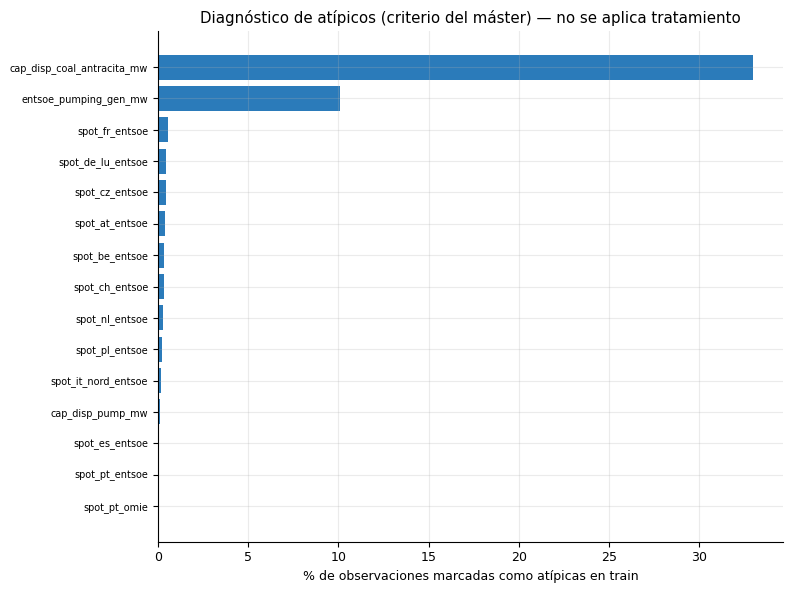

In [11]:
candidatas_diag = [c for c in numericas_bronce if c not in descartadas][:60]
filas = []
for c in candidatas_diag:
    serie = df.loc[TRAIN, c]
    if serie.notna().sum() < 500 or serie.nunique() < 10:
        continue
    _, n_at = atipicosAmissing(serie)
    filas.append({"variable": c, "n_atipicos": int(n_at),
                  "% train": n_at / serie.notna().sum() * 100,
                  "asimetria": serie.skew()})
AT = pd.DataFrame(filas).set_index("variable").sort_values("% train", ascending=False)
display(AT.head(15).round(3))

top = AT[AT["n_atipicos"] > 0].head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 0.32 * len(top) + 1.2))
ax.barh(top.index, top["% train"], color=PALETA["secundario"])
ax.set_xlabel("% de observaciones marcadas como atípicas en train")
ax.set_title("Diagnóstico de atípicos (criterio del máster) — no se aplica tratamiento")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.show()

In [12]:
n_obj = int(AT.loc[P, "n_atipicos"]) if P in AT.index else 0
print(f"El propio objetivo tiene {n_obj:,} valores marcados como atípicos "
      f"({n_obj / TRAIN.sum() * 100:.2f} % de train).")
print("Aplicar el tratamiento del máster los convertiría en perdidos y después los imputaría")
print("por la media: el modelo dejaría de ver precisamente las horas que dan el margen.")

DEC.anotar("A.2", "Diagnóstico de atípicos ejecutado, tratamiento NO aplicado", "razonado",
           "En este dominio el valor extremo es el fenómeno, no un error de medida. Se "
           "corrigen sólo los imposibles físicos, identificados uno a uno en el apartado 2.")

El propio objetivo tiene 6 valores marcados como atípicos (0.01 % de train).
Aplicar el tratamiento del máster los convertiría en perdidos y después los imputaría
por la media: el modelo dejaría de ver precisamente las horas que dan el margen.
  [A.2] razonado: Diagnóstico de atípicos ejecutado, tratamiento NO aplicado


## 3.2 · El patrón de los valores perdidos

Antes de imputar hay que saber si los nulos aparecen juntos. Si dos columnas se quedan vacías a la
vez, comparten causa —el mismo corte de ingesta— y no se pueden imputar de forma independiente
como si fueran ausencias al azar.

53 columnas con nulos en train, de 75 candidatas.


,% nulos en train
esios_gen_ree_cbattery_mw,99.22
esios_gen_ree_gbattery_mw,99.22
cap_inst_battery_hybrid_mw,99.16
cap_inst_wind_hybrid_mw,99.09
cap_inst_solar_pv_hybrid_mw,98.68
commodities_co2_eua_dec,97.09
commodities_gas_ttf_m1,97.08
cap_inst_coal_mw,95.83
cap_inst_solar_pv_mw,95.83
cap_inst_wind_mw,95.83


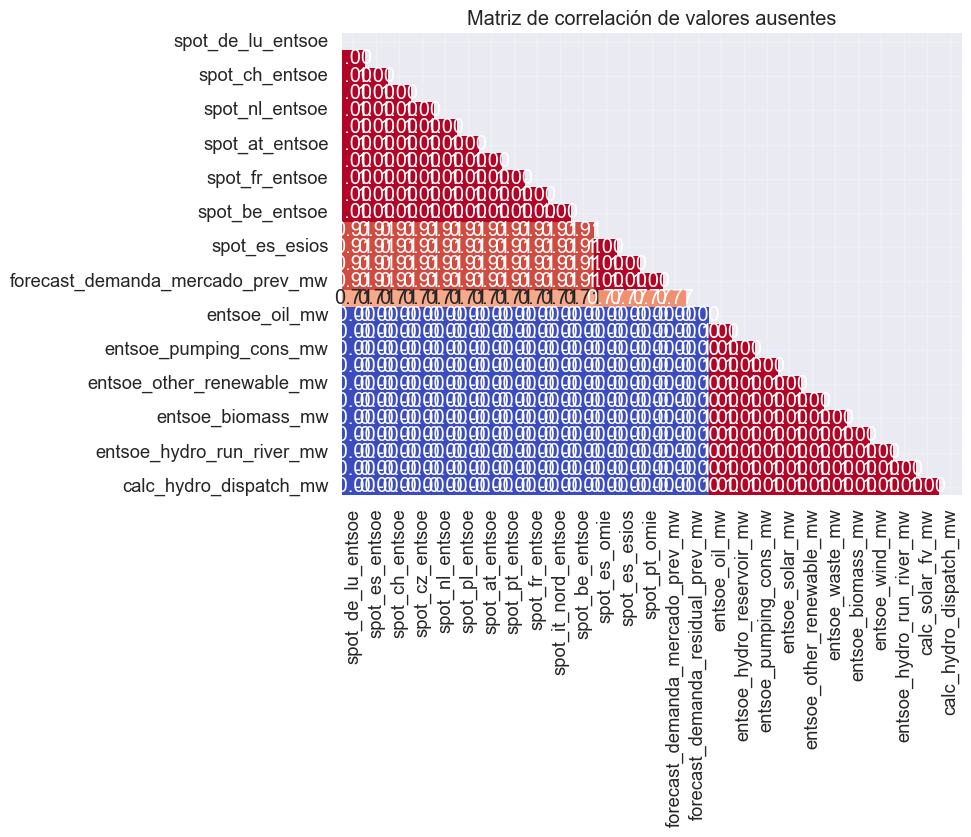

In [13]:
util = [c for c in numericas_bronce if c not in descartadas]
prop = df.loc[TRAIN, util].isna().mean()
con_nulos = prop[prop > 0].sort_values(ascending=False)
print(f"{len(con_nulos)} columnas con nulos en train, de {len(util)} candidatas.")
display(con_nulos.head(12).mul(100).round(2).rename("% nulos en train").to_frame())

# Las estructurales (tabla diaria o paso trihorario) no informan del patrón: se excluyen.
no_estructurales = [c for c in con_nulos.index
                    if not c.startswith(("cap_", "commodities_")) and con_nulos[c] < 0.60]
if len(no_estructurales) > 2:
    patron_perdidos(df.loc[TRAIN, no_estructurales])
else:
    print("\nMenos de tres columnas con nulos no estructurales: el mapa de patrón no aporta.")

## 3.3 · `prop_missings` como variable

El máster construye una variable con la proporción de valores ausentes de cada observación, bajo
la idea de que «faltar» puede ser informativo. Aquí lo es de forma muy concreta: una hora con
muchos nulos es una hora en que la ingesta falló, y ese fallo tiene una distribución temporal
—no aleatoria— que el modelo puede aprovechar o que, al menos, conviene poder aislar.

In [14]:
df["prop_missings"] = df[no_estructurales].isna().mean(axis=1) if no_estructurales else 0.0
display(df.loc[TRAIN, "prop_missings"].describe().round(4).to_frame().T)

exceso = df["prop_missings"] > 0.5
print(f"\nObservaciones con más de la mitad de las columnas ausentes: {int(exceso.sum())}")
if exceso.any():
    print("Se eliminan, siguiendo el criterio del máster.")
    df = df[~exceso].copy()
    TRAIN = df["split"] == "train"

,count,mean,std,min,25%,50%,75%,max
prop_missings,43872.0,0.0001,0.0068,0.0,0.0,0.0,0.0,0.5926



Observaciones con más de la mitad de las columnas ausentes: 6
Se eliminan, siguiendo el criterio del máster.


## 3.4 · Imputación

La imputación por la media que emplea `VinoDep.py` es correcta para observaciones independientes.
En una serie horaria es la peor opción disponible: sustituye un hueco de tres horas de un martes
de agosto por la media de seis años, introduciendo un escalón donde no lo había.

Se imputa por **interpolación temporal con límite**, que respeta la continuidad de la serie, y se
deja constancia de la desviación respecto al procedimiento de clase. El límite existe para que un
hueco largo —que es un problema de ingesta, no una ausencia puntual— no se rellene inventando una
recta de días.

In [15]:
LIMITE_H = 3
cols_imputar = [c for c in no_estructurales if df.loc[TRAIN, c].isna().any()]
antes = df[cols_imputar].isna().sum().sum()

df = df.sort_values("ts_utc")
df[cols_imputar] = (df[cols_imputar]
                    .interpolate(method="linear", limit=LIMITE_H, limit_direction="both"))
despues = df[cols_imputar].isna().sum().sum()

print(f"Nulos antes de imputar : {antes:,}")
print(f"Nulos después          : {despues:,}  ({(antes - despues) / max(antes, 1) * 100:.1f} % resueltos)")
if despues:
    resto = df[cols_imputar].isna().sum()
    print("\nHuecos que superan el límite y quedan declarados como perdidos:")
    display(resto[resto > 0].rename("nulos restantes").to_frame().T)

DEC.anotar("A.3", "Imputación por interpolación temporal en lugar de por la media", "aplicado",
           f"Límite de {LIMITE_H} horas. La media del máster introduce un escalón en una serie "
           "temporal; la interpolación respeta la continuidad. Los huecos largos se dejan "
           "declarados en vez de inventarse.")

Nulos antes de imputar : 431
Nulos después          : 337  (21.8 % resueltos)

Huecos que superan el límite y quedan declarados como perdidos:


,spot_it_nord_entsoe,entsoe_oil_mw,entsoe_hydro_reservoir_mw,entsoe_pumping_cons_mw,entsoe_solar_mw,entsoe_other_renewable_mw,entsoe_waste_mw,entsoe_biomass_mw,entsoe_wind_mw,entsoe_hydro_run_river_mw,calc_solar_fv_mw,calc_hydro_dispatch_mw
nulos restantes,18,29,29,29,29,29,29,29,29,29,29,29


  [A.3] aplicado: Imputación por interpolación temporal en lugar de por la media


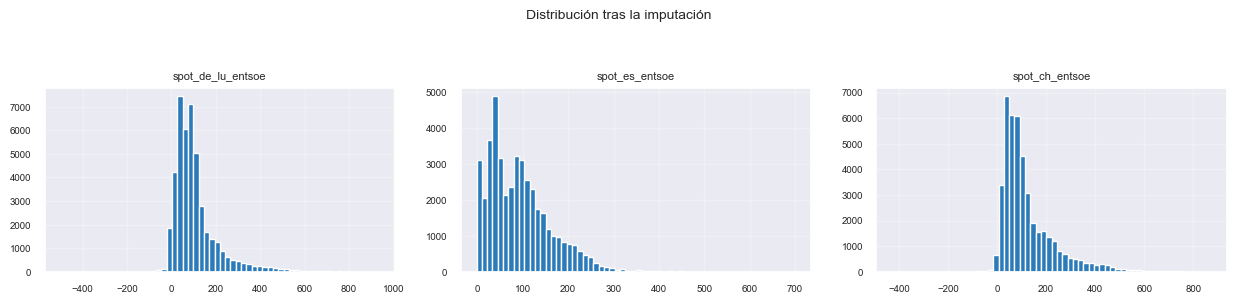

In [16]:
# Control visual: la imputación no debe alterar la forma de la distribución.
control = [c for c in cols_imputar if df.loc[TRAIN, c].notna().sum() > 1000][:3]
if control:
    fig, axes = plt.subplots(1, len(control), figsize=(4.2 * len(control), 3))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, control):
        ax.hist(df.loc[TRAIN, c].dropna(), bins=60, color=PALETA["secundario"])
        ax.set_title(c[:34], fontsize=8); ax.tick_params(labelsize=7)
    fig.suptitle("Distribución tras la imputación", y=1.02, fontsize=10)
    plt.tight_layout(); plt.show()

---
# 4 · Construcción de la matriz

Hasta aquí el cuaderno ha corregido lo que estaba mal. A partir de aquí **crea variables que no
existían**, que es lo que distingue la ingeniería de variables de la depuración.

La construcción se hace sobre la rejilla objetivo: una fila por (día objetivo, hora), con cada
familia desplazada según el desfase que le corresponde en la tabla del encabezado.

## 4.1 · La rejilla objetivo y la alineación temporal

In [17]:
H_DIA, H_SEMANA = 24, 168
DESFASE_REAL = 48       # dos días: lo último cerrado a las 12:00 del día de predicción

# `.values` sobre una columna con zona horaria la descarta, y un reindex posterior contra un
# índice con zona no casaría con nada: devolvería nulos en silencio. Se reinicia el índice en
# lugar de extraer el array.
M = pd.DataFrame({"ts": df["ts_utc"].reset_index(drop=True),
                  "ts_local": df["ts_local"].reset_index(drop=True)})
M["hora"] = df["hora"].values
M["fecha_objetivo"] = M["ts_local"].dt.normalize()
M["fecha_pred"] = M["fecha_objetivo"] - pd.Timedelta(days=1)
M["split"] = df["split"].values
M["regimen"] = df["regimen"].values
M["target_price"] = df[P].values

# Serie horaria continua: los retardos se toman sobre ella, no sobre el orden de las filas.
serie = df.set_index("ts_utc").asfreq("h")

# Valor de `col` tantas horas antes del instante objetivo, sobre la rejilla horaria completa.
def retardar(col: str, horas: int) -> np.ndarray:
    return serie[col].shift(horas).reindex(M["ts"]).values

print(f"Rejilla objetivo: {len(M):,} filas × (día objetivo, hora)")
print(f"Desfase de las variables reales: {DESFASE_REAL} h (= día anterior al de predicción)")

Rejilla objetivo: 58,313 filas × (día objetivo, hora)
Desfase de las variables reales: 48 h (= día anterior al de predicción)


## 4.2 · Retardos del precio *(P.1)*

El EDA midió la autocorrelación y encontró dos retardos que sostienen la estructura: el de 24
horas —la misma hora del día ya casado— y el de 168 —la misma hora del mismo día de la semana
anterior—, con la particularidad de que la utilidad del primero **depende del día de la semana**.

Aquí se construyen ambos, más los agregados diarios que resumen el nivel y la forma del día
anterior, y se comprueba sobre `train` cuál domina.

In [18]:
M["precio_lag24"] = retardar(P, H_DIA)
M["precio_lag168"] = retardar(P, H_SEMANA)

# Agregados del último día de precios conocido: nivel, dispersión y posición relativa.
dia_prev = (serie[P].resample("D").agg(["mean", "min", "max"])
            .rename(columns={"mean": "precio_d_media", "min": "precio_d_min",
                             "max": "precio_d_max"}))
dia_prev["precio_d_rango"] = dia_prev["precio_d_max"] - dia_prev["precio_d_min"]
dia_prev.index = dia_prev.index.tz_convert(TZ).normalize()

# El día de precios completo a las 12:00 de D es el propio D, es decir, objetivo − 1 día.
llave = (M["fecha_objetivo"] - pd.Timedelta(days=1))
for c in dia_prev.columns:
    M[c] = llave.map(dia_prev[c]).values

# Posición relativa de la hora dentro de la curva del día anterior: normaliza el nivel.
rango = (M["precio_d_rango"]).replace(0, np.nan)
M["precio_lag24_rel"] = (M["precio_lag24"] - M["precio_d_min"]) / rango

RET = pd.DataFrame({
    "r con el objetivo (train)": {
        c: M.loc[M["split"] == "train", c].corr(M.loc[M["split"] == "train", "target_price"])
        for c in ["precio_lag24", "precio_lag168", "precio_d_media", "precio_d_max",
                  "precio_d_min", "precio_d_rango", "precio_lag24_rel"]}})
display(RET.round(4).sort_values("r con el objetivo (train)", ascending=False))

DEC.anotar("P.1", "Retardos del precio construidos: 24 h, 168 h y agregados del día previo",
           "aplicado",
           "Ambos retardos entran; el EDA mostró que su utilidad relativa cambia según el día "
           "de la semana, así que se deja que el modelo pondere en vez de elegir uno.")

,r con el objetivo (train)
precio_lag24,0.9167
precio_d_media,0.8997
precio_d_max,0.8848
precio_d_min,0.8393
precio_lag168,0.8301
precio_d_rango,0.4816
precio_lag24_rel,0.1894


  [P.1] aplicado: Retardos del precio construidos: 24 h, 168 h y agregados del día previo


### La interacción del retardo con el día de la semana

El hallazgo `P.1` no se agota construyendo los dos retardos: pedía **la interacción**. Se
construye de la forma que el máster emplea para las interacciones —el producto de la variable por
la indicadora de cada categoría— pero agrupando los días en los tres regímenes que el EDA
distinguió, en lugar de en siete, para no multiplicar por siete el número de columnas.

In [19]:
M["dow"] = M["ts_local"].dt.dayofweek
M["tipo_dia"] = np.select(
    [M["dow"] <= 3, M["dow"] == 4, M["dow"] == 5],
    ["laborable", "viernes", "sabado"], default="domingo")

for cat in ["laborable", "viernes", "sabado", "domingo"]:
    M[f"lag24_x_{cat}"] = M["precio_lag24"] * (M["tipo_dia"] == cat)

tr = M["split"] == "train"
comp = pd.DataFrame({
    "r(lag24, objetivo)": M[tr].groupby("tipo_dia").apply(
        lambda g: g["precio_lag24"].corr(g["target_price"]), include_groups=False),
    "r(lag168, objetivo)": M[tr].groupby("tipo_dia").apply(
        lambda g: g["precio_lag168"].corr(g["target_price"]), include_groups=False)})
comp["gana el semanal"] = comp["r(lag168, objetivo)"] > comp["r(lag24, objetivo)"]
display(comp.round(4))

,"r(lag24, objetivo)","r(lag168, objetivo)",gana el semanal
tipo_dia,,,
domingo,0.9092,0.8103,False
laborable,0.9171,0.8201,False
sabado,0.9187,0.8438,False
viernes,0.9463,0.8645,False


## 4.3 · Variables derivadas del sistema

Tres derivadas que el EDA justificó y que no existen como columna en el bronce.

**La demanda residual prevista** es la variable fundamental del mercado: lo que queda de la
demanda una vez descontada la renovable que no tiene coste variable, y por tanto lo que fija el
precio a través de la curva de oferta del apartado 6.4 del EDA. Se construye **con las tres
previsiones**, de modo que hereda su etiqueta `SIN FUGA` por construcción; calcularla con las
magnitudes reales la contaminaría.

**Los grados-día** responden al hallazgo `P.6`: la demanda depende de la temperatura en forma de
U, y un término lineal no captura eso. Se parte la temperatura en sus dos ramas.

**La cobertura renovable prevista** normaliza la penetración renovable por el tamaño de la
demanda, que es lo que determina si el excedente aprieta el precio o no.

In [20]:
UMBRAL_C = 18.0

if FC_DEM and FC_EOL and FC_FV:
    M["demanda_residual_prev"] = (df[FC_DEM].values - df[FC_EOL].values - df[FC_FV].values)
    M["cobertura_renovable_prev"] = ((df[FC_EOL].values + df[FC_FV].values)
                                     / np.where(df[FC_DEM].values > 0, df[FC_DEM].values, np.nan))
    for c, src in [("demanda_prev", FC_DEM), ("eolica_prev", FC_EOL), ("solar_prev", FC_FV)]:
        M[c] = df[src].values

if T2M:
    t2m = retardar(T2M, DESFASE_REAL)
    t2m = t2m - 273.15 if np.nanmean(t2m) > 200 else t2m      # ERA5 publica en Kelvin
    M["temp_Dm1"] = t2m
    M["hdd_Dm1"] = np.clip(UMBRAL_C - t2m, 0, None)
    M["cdd_Dm1"] = np.clip(t2m - UMBRAL_C, 0, None)

tr = M["split"] == "train"
derivadas = [c for c in ["demanda_residual_prev", "cobertura_renovable_prev",
                         "temp_Dm1", "hdd_Dm1", "cdd_Dm1"] if c in M.columns]
DER = pd.DataFrame({"r con el objetivo (train)": {c: M.loc[tr, c].corr(M.loc[tr, "target_price"])
                                                  for c in derivadas}})
display(DER.round(4))

if {"temp_Dm1", "hdd_Dm1", "cdd_Dm1"} <= set(M.columns):
    print(f"\nLa temperatura lineal correlaciona {DER.loc['temp_Dm1'].iat[0]:+.4f} con el precio;")
    print(f"partida en grados-día, {DER.loc['hdd_Dm1'].iat[0]:+.4f} (frío) y "
          f"{DER.loc['cdd_Dm1'].iat[0]:+.4f} (calor).")
    DEC.anotar("P.6", "Temperatura sustituida por grados-día de frío y de calor", "aplicado",
               "La relación en U del EDA no la capta un término lineal. Se conservan las tres "
               "columnas para poder contrastar.")

,r con el objetivo (train)
demanda_residual_prev,0.3627
cobertura_renovable_prev,-0.3246
temp_Dm1,-0.0476
hdd_Dm1,0.0783
cdd_Dm1,0.0049



La temperatura lineal correlaciona -0.0476 con el precio;
partida en grados-día, +0.0783 (frío) y +0.0049 (calor).
  [P.6] aplicado: Temperatura sustituida por grados-día de frío y de calor


## 4.4 · Las variables con fuga, incorporadas con su retardo

La generación y la demanda reales son consecuencia de la casación, no antecedente, y el EDA lo
dejó claro: su correlación con el precio es espectacular y completamente inutilizable en directo.
Con dos días de retardo dejan de ser fuga y pasan a ser lo que realmente son: **el estado del
sistema la última vez que se pudo observar**.

In [21]:
CON_FUGA_UTILES = [c for c in [DEM, EOL, FV, HID, CCGT, PG, PC,
                               cm.pick(df, "esios_gen_ree_gnuclear_mw"),
                               cm.pick(df, "load_inter_total_net_flow_mw"),
                               cm.pick(df, "load_inter_ree_netflow_fr"),
                               cm.pick(df, "load_inter_ree_netflow_pt")]
                   if c and c not in descartadas]

for c in CON_FUGA_UTILES:
    M[f"{c}_Dm1"] = retardar(c, DESFASE_REAL)

print(f"{len(CON_FUGA_UTILES)} magnitudes reales incorporadas con retardo de dos días:")
for c in CON_FUGA_UTILES:
    print(f"  {c} → {c}_Dm1")

DEC.anotar("A.4", "Magnitudes reales incorporadas sólo con retardo de dos días", "aplicado",
           "Sin retardo son consecuencia de la misma casación que el precio. Con él, "
           "describen el estado del sistema la última vez observable.")

11 magnitudes reales incorporadas con retardo de dos días:
  load_inter_entsoe_load → load_inter_entsoe_load_Dm1
  entsoe_wind_mw → entsoe_wind_mw_Dm1
  calc_solar_fv_mw → calc_solar_fv_mw_Dm1
  calc_hydro_dispatch_mw → calc_hydro_dispatch_mw_Dm1
  esios_gen_ree_gccgas_mw → esios_gen_ree_gccgas_mw_Dm1
  entsoe_pumping_gen_mw → entsoe_pumping_gen_mw_Dm1
  entsoe_pumping_cons_mw → entsoe_pumping_cons_mw_Dm1
  esios_gen_ree_gnuclear_mw → esios_gen_ree_gnuclear_mw_Dm1
  load_inter_total_net_flow_mw → load_inter_total_net_flow_mw_Dm1
  load_inter_ree_netflow_fr → load_inter_ree_netflow_fr_Dm1
  load_inter_ree_netflow_pt → load_inter_ree_netflow_pt_Dm1
  [A.4] aplicado: Magnitudes reales incorporadas sólo con retardo de dos días


## 4.5 · Commodities con el desfase que les corresponde

Los cierres de gas y CO2 son diarios y se producen a las 17:30, después del cierre eléctrico. El
último disponible al predecir es el del día anterior al de predicción, es decir, dos días antes
del objetivo — la etiqueta `DESFASE D-2` de la frontera.

In [22]:
COMMOD = [c for c in [GAS, CO2, cm.pick(df, "commodities_gas_mibgas")] if c]
diarias = (serie[COMMOD].resample("D").mean().ffill())
diarias.index = diarias.index.tz_convert(TZ).normalize()

llave_c = M["fecha_objetivo"] - pd.Timedelta(days=2)
for c in COMMOD:
    M[f"{c}_Dm2"] = llave_c.map(diarias[c]).values

tr = M["split"] == "train"
display(pd.DataFrame({"r con el objetivo (train)": {
    f"{c}_Dm2": M.loc[tr, f"{c}_Dm2"].corr(M.loc[tr, "target_price"]) for c in COMMOD}}).round(4))

if GAS and CCGT:
    # El coste marginal del ciclo combinado es lo que fija el precio cuando marca la térmica.
    RENDIMIENTO, FACTOR_CO2 = 0.55, 0.37
    M["coste_ccgt_Dm2"] = (M[f"{GAS}_Dm2"] / RENDIMIENTO
                           + M.get(f"{CO2}_Dm2", 0) * FACTOR_CO2 / RENDIMIENTO)
    print(f"\ncoste_ccgt_Dm2 (gas/η + CO2·factor/η): r = "
          f"{M.loc[tr, 'coste_ccgt_Dm2'].corr(M.loc[tr, 'target_price']):.4f}")
    print("Combina las dos commodities en la magnitud que el mercado realmente usa para ofertar.")

DEC.anotar("A.5", "Commodities incorporadas con desfase de dos días y coste del CCGT derivado",
           "aplicado",
           "Cierran tras el cierre eléctrico. El coste marginal del ciclo combinado combina "
           "gas y CO2 en la magnitud con la que se oferta.")

,r con el objetivo (train)
commodities_gas_ttf_m1_Dm2,0.6363
commodities_co2_eua_dec_Dm2,0.4961
commodities_gas_mibgas_Dm2,0.7445



coste_ccgt_Dm2 (gas/η + CO2·factor/η): r = 0.6548
Combina las dos commodities en la magnitud que el mercado realmente usa para ofertar.
  [A.5] aplicado: Commodities incorporadas con desfase de dos días y coste del CCGT derivado


## 4.6 · Calendario *(P.0, P.2)*

La hora y el día de la semana no son números: son **ciclos**. Codificarlos como enteros le dice
al modelo que las 23:00 y las 00:00 distan veintitrés unidades, cuando distan una. La codificación
en seno y coseno respeta la circularidad.

Se añaden además dos variables que responden a hallazgos concretos: la **antigüedad** de la
observación, para que el modelado pueda ponderar el histórico ante la no estacionariedad del
perfil horario (`P.0`), y la **indicadora de régimen** (`P.2`).

In [23]:
M["hora_sin"] = np.sin(2 * np.pi * M["hora"] / 24)
M["hora_cos"] = np.cos(2 * np.pi * M["hora"] / 24)
M["dow_sin"] = np.sin(2 * np.pi * M["dow"] / 7)
M["dow_cos"] = np.cos(2 * np.pi * M["dow"] / 7)
M["mes"] = M["ts_local"].dt.month
M["mes_sin"] = np.sin(2 * np.pi * M["mes"] / 12)
M["mes_cos"] = np.cos(2 * np.pi * M["mes"] / 12)
M["finde"] = (M["dow"] >= 5).astype(int)

try:
    import holidays
    festivos = holidays.country_holidays("ES", years=range(2020, 2027))
    M["festivo"] = M["fecha_objetivo"].dt.date.map(lambda d: int(d in festivos))
except Exception as e:                                   # sin la librería, se degrada con aviso
    M["festivo"] = 0
    print(f"AVISO: festivos no disponibles ({e}); la columna queda a cero.")

M["antiguedad_dias"] = (M["fecha_objetivo"].max() - M["fecha_objetivo"]).dt.days
# prop_missings, del apartado 3.3, retardada como todo lo observado: informa de la calidad de
# la ingesta del último día visible, no de la del día que se quiere predecir.
M["prop_missings_Dm1"] = retardar("prop_missings", DESFASE_REAL)
M["reg_excepcion"] = (M["regimen"] == "excepción ibérica").astype(int)
M["reg_apagon"] = (M["regimen"] == "apagón").astype(int)

cap_fv = cm.pick(df, "cap_inst_solar_pv_mw")
if cap_fv:
    M["cap_fv_instalada"] = pd.Series(serie[cap_fv].ffill().reindex(M["ts"]).values)

cal = ["hora_sin", "hora_cos", "dow_sin", "dow_cos", "mes_sin", "mes_cos", "finde", "festivo",
       "antiguedad_dias", "prop_missings_Dm1", "reg_excepcion", "reg_apagon"] \
      + (["cap_fv_instalada"] if cap_fv else [])
print(f"{len(cal)} variables de calendario y contexto construidas.")
display(M.loc[M['split'] == 'train', cal].describe().T[["mean", "std", "min", "max"]].round(3))

DEC.anotar("P.0", "Antigüedad y capacidad FV instalada incorporadas como regresores", "aplicado",
           "Dan al modelado la doble vía que el EDA planteaba ante la no estacionariedad: "
           "ponderar el histórico por antigüedad, o explicar el cambio con la capacidad.")
DEC.anotar("P.2", "Regímenes marcados con indicadoras en lugar de eliminarse", "aplicado",
           "Eliminar el apagón deja 2025 incompleta y rompe cualquier ventana temporal sin "
           "avisar. Marcado, el modelado decide.")

13 variables de calendario y contexto construidas.


,mean,std,min,max
hora_sin,-0.000,0.707,-1.000,1.000
hora_cos,-0.000,0.707,-1.000,1.000
dow_sin,0.001,0.707,-0.975,0.975
dow_cos,-0.000,0.707,-0.901,1.000
mes_sin,-0.004,0.706,-1.000,1.000
mes_cos,-0.001,0.709,-1.000,1.000
finde,0.285,0.452,0.000,1.000
festivo,0.024,0.153,0.000,1.000
antiguedad_dias,1515.075,527.692,601.000,2428.000
prop_missings_Dm1,0.000,0.003,0.000,0.407


  [P.0] aplicado: Antigüedad y capacidad FV instalada incorporadas como regresores
  [P.2] aplicado: Regímenes marcados con indicadoras en lugar de eliminarse


## 4.7 · Interacciones con la hora del día *(P.3)*

El EDA midió que la asociación de los drivers con el precio cambia a lo largo del día, con
amplitudes superiores a 0,3 en varios de ellos. La consecuencia directa es que el efecto de un
driver debe poder depender de la hora.

Se construye el producto por la codificación cíclica —no por la hora entera, que reintroduciría
la falsa distancia entre las 23 y las 0— y se limita a los drivers admisibles con mayor amplitud,
para no duplicar la matrix entera.

In [24]:
CANDIDATAS_INTER = [c for c in ["demanda_residual_prev", "solar_prev", "eolica_prev",
                                "precio_lag24"] if c in M.columns]
for c in CANDIDATAS_INTER:
    M[f"{c}_x_horasin"] = M[c] * M["hora_sin"]
    M[f"{c}_x_horacos"] = M[c] * M["hora_cos"]

# Interaccion gas x cobertura renovable, que responde a los hallazgos P.10 y P.13: el coste del
# ciclo combinado marca el precio SOLO cuando la termica esta en el margen, es decir cuando la
# renovable no cubre. Se construye sobre la cobertura PREVISTA, que es la disponible al predecir.
if "coste_ccgt_Dm2" in M.columns and "cobertura_renovable_prev" in M.columns:
    M["hueco_termico_prev"] = (1 - M["cobertura_renovable_prev"]).clip(lower=0)
    M["coste_ccgt_x_hueco"] = M["coste_ccgt_Dm2"] * M["hueco_termico_prev"]

inter_cols = [f"{c}_x_hora{s}" for c in CANDIDATAS_INTER for s in ("sin", "cos")]
inter_cols += [c for c in ("coste_ccgt_x_hueco",) if c in M.columns]
tr = M["split"] == "train"
comparacion = pd.DataFrame({
    "r base": {c: abs(M.loc[tr, c].corr(M.loc[tr, "target_price"])) for c in CANDIDATAS_INTER},
    "r mejor interacción": {c: max(abs(M.loc[tr, f"{c}_x_horasin"].corr(M.loc[tr, "target_price"])),
                                   abs(M.loc[tr, f"{c}_x_horacos"].corr(M.loc[tr, "target_price"])))
                            for c in CANDIDATAS_INTER}})
display(comparacion.round(4))

if "coste_ccgt_x_hueco" in M.columns:
    tr = M["split"] == "train"
    r_solo = abs(M.loc[tr, "coste_ccgt_Dm2"].corr(M.loc[tr, "target_price"]))
    r_int = abs(M.loc[tr, "coste_ccgt_x_hueco"].corr(M.loc[tr, "target_price"]))
    print("")
    print(f"Coste del CCGT, solo          : |r| = {r_solo:.4f}")
    print(f"Coste del CCGT x hueco térmico : |r| = {r_int:.4f}")
    print("Responde a los hallazgos P.10 y P.13: el gas marca el precio sólo cuando la térmica")
    print("está en el margen. Se conservan las dos versiones para que el modelado decida.")

DEC.anotar("P.3", f"{len(inter_cols)} interacciones construidas", "aplicado",
           "Con la hora del día, por producto con la codificación cíclica y no con la hora "
           "entera, respondiendo a la amplitud horaria medida en el EDA. Y una interacción "
           "entre el coste del ciclo combinado y el hueco térmico previsto (P.10 y P.13).")

,r base,r mejor interacción
demanda_residual_prev,0.3627,0.0607
solar_prev,0.1573,0.1369
eolica_prev,0.1738,0.0713
precio_lag24,0.9167,0.0865



Coste del CCGT, solo          : |r| = 0.6548
Coste del CCGT x hueco térmico : |r| = 0.7376
Responde a los hallazgos P.10 y P.13: el gas marca el precio sólo cuando la térmica
está en el margen. Se conservan las dos versiones para que el modelado decida.
  [P.3] aplicado: 9 interacciones construidas


## 4.8 · Transformaciones *(P.4)*

Último paso de la construcción, y el que sigue más de cerca el procedimiento del máster:
`mejorTransfCorr` prueba siete transformaciones —identidad, logaritmo, exponencial, cuadrado,
raíz, cuarta potencia y raíz cuarta— y se queda con la que maximiza la correlación con el
objetivo.

**Es también el procedimiento más discutible de todo el cuaderno, y conviene decirlo.** El
apartado 0.2 lo califica de *dragado de datos* cuando se aplica sin
control: elegir una transformación porque maximiza la correlación con el objetivo incorpora a la
elección el ruido de la muestra, y sobre decenas de miles de observaciones **algo siempre
mejora**.

Ese mismo apartado establece la única forma válida de usarlo, que es la que se sigue aquí:

1. la búsqueda se realiza **sólo sobre `train`**;
2. la ganancia obtenida se **verifica después en `validation`**, que no ha intervenido en la
   elección;
3. se conserva únicamente la transformación cuya mejora **persiste fuera de la muestra**.

Una transformación que gana en entrenamiento y pierde en validación era ruido, y el
procedimiento lo demuestra en lugar de suponerlo. Se aplica sólo a las variables que el EDA
señaló como no lineales (`P.4`).

In [25]:
CANDIDATAS_TRANSF = [c for c in ["demanda_residual_prev", "solar_prev", "eolica_prev",
                                 "cobertura_renovable_prev", "hdd_Dm1", "cdd_Dm1"]
                     if c in M.columns]

tr = M["split"] == "train"
filas = []
for c in CANDIDATAS_TRANSF:
    # Un dropna por variable, no conjunto: la meteorología tiene paso trihorario y un dropna
    # sobre todas las candidatas a la vez reduciría la búsqueda a las horas en que coinciden.
    base = M.loc[tr, [c, "target_price"]].dropna()
    if len(base) < 500:
        print(f"AVISO: {c} tiene {len(base)} observaciones en train; se omite.")
        continue
    nombre, transformada = mejorTransfCorr(base[c], base["target_price"])
    r_orig = abs(base[c].corr(base["target_price"]))
    r_new = abs(np.corrcoef(base["target_price"], transformada)[0, 1])
    filas.append({"variable": c, "n train": len(base), "mejor transf.": nombre,
                  "|r| original": r_orig, "|r| transformada": r_new,
                  "ganancia": r_new - r_orig})
TRANSF = pd.DataFrame(filas).set_index("variable").sort_values("ganancia", ascending=False)
display(TRANSF.round(4))

,n train,mejor transf.,|r| original,|r| transformada,ganancia
variable,,,,,
hdd_Dm1,14598,sqrx,0.0783,0.0967,0.0184
solar_prev,43867,expx,0.1573,0.1750,0.0177
eolica_prev,43867,sqrx,0.1738,0.1907,0.0169
cobertura_renovable_prev,43867,sqrx,0.3246,0.3395,0.0149
demanda_residual_prev,43867,raiz4,0.3627,0.3733,0.0106
cdd_Dm1,14598,sqrtx,0.0049,0.0060,0.0011


In [26]:
# Se aplican al conjunto completo únicamente las que ganan de forma apreciable en train.
UMBRAL_GANANCIA = 0.01
candidatas_ok = TRANSF[(TRANSF["ganancia"] > UMBRAL_GANANCIA) & (TRANSF["mejor transf."] != "x")]

FORMULAS = {"logx": np.log, "expx": np.exp, "sqrx": lambda v: v ** 2,
            "sqrtx": np.sqrt, "cuartax": lambda v: v ** 4, "raiz4": lambda v: v ** 0.25}

# Los parámetros de normalización se calculan en TRAIN y se congelan: recalcularlos sobre
# validación sería usar ese tramo dos veces, para elegir y para evaluar.
def aplicar_transformacion(col, nombre_transf):
    mu, sd = M.loc[tr, col].mean(), M.loc[tr, col].std()
    z = (M[col] - mu) / sd
    z = z + abs(M.loc[tr, col].sub(mu).div(sd).min()) * 1.0001
    return FORMULAS[nombre_transf](z.clip(lower=1e-9))

va = M["split"] == "validation"
filas = []
for c, fila in candidatas_ok.iterrows():
    serie_t = aplicar_transformacion(c, fila["mejor transf."])
    g_val = (abs(serie_t[va].corr(M.loc[va, "target_price"]))
             - abs(M.loc[va, c].corr(M.loc[va, "target_price"])))
    filas.append({"variable": c, "transf.": fila["mejor transf."],
                  "ganancia en train": fila["ganancia"], "ganancia en validación": g_val,
                  "persiste": bool(g_val > 0)})
VAL = pd.DataFrame(filas).set_index("variable")
display(VAL.round(4))

transformadas = []
for c, fila in VAL[VAL["persiste"]].iterrows():
    nombre = f"{fila['transf.']}_{c}"
    M[nombre] = aplicar_transformacion(c, fila["transf."])
    transformadas.append(nombre)

descartadas_t = VAL[~VAL["persiste"]].index.tolist()
print(f"\nCandidatas que ganaban en train : {len(VAL)}")
print(f"Conservadas tras la verificación : {len(transformadas)}")
if descartadas_t:
    print(f"Descartadas por no persistir     : {', '.join(descartadas_t)}")
    print("\nSu mejora en entrenamiento era ruido de la muestra. Es exactamente el dragado de")
    print("datos que advierte el apartado 0.2, detectado por la única vía que lo detecta:")
    print("mirar un tramo que no participó en la elección.")
for t_ in transformadas:
    print(f"  conservada: {t_}")

DEC.anotar("P.4", f"{len(transformadas)} transformaciones conservadas de {len(VAL)} candidatas",
           "aplicado",
           "Búsqueda con mejorTransfCorr sobre train y verificación en validación: se conservan "
           f"sólo las que siguen ganando fuera de la muestra ({len(descartadas_t)} descartadas "
           "por no persistir). Parámetros de normalización congelados en train.")

,transf.,ganancia en train,ganancia en validación,persiste
variable,,,,
hdd_Dm1,sqrx,0.0184,0.0400,True
solar_prev,expx,0.0177,-0.1023,False
eolica_prev,sqrx,0.0169,0.0086,True
cobertura_renovable_prev,sqrx,0.0149,-0.0411,False
demanda_residual_prev,raiz4,0.0106,-0.0610,False



Candidatas que ganaban en train : 5
Conservadas tras la verificación : 2
Descartadas por no persistir     : solar_prev, cobertura_renovable_prev, demanda_residual_prev

Su mejora en entrenamiento era ruido de la muestra. Es exactamente el dragado de
datos que advierte el apartado 0.2, detectado por la única vía que lo detecta:
mirar un tramo que no participó en la elección.
  conservada: sqrx_hdd_Dm1
  conservada: sqrx_eolica_prev
  [P.4] aplicado: 2 transformaciones conservadas de 5 candidatas


---
# 5 · Los dos objetivos

El máster distingue `varObjCont` y `varObjBin`. Aquí ocurre lo mismo, y por una razón de negocio
más que estadística: el bloque 7 del EDA mostró que para operar una batería la decisión relevante
no es cuánto valdrá el MWh sino **si esta hora es de cargar o de descargar**.

El objetivo categórico se construye con la misma función del módulo compartido que usó el EDA, de
modo que la definición no puede divergir entre los dos cuadernos.

In [27]:
clases = clasificar_horas(
    M.assign(dia=M["fecha_objetivo"].dt.date, anio=M["ts_local"].dt.year), "target_price", K_HORAS)
M["clase_precio"] = clases["clase"].reindex(M.index)
M["es_cara"] = clases["es_cara"].reindex(M.index)

tr = M["split"] == "train"
print("Objetivo continuo:")
display(M.loc[tr, "target_price"].describe().round(2).to_frame().T)
print("\nObjetivo categórico (reparto en train):")
display(M.loc[tr, "clase_precio"].value_counts(normalize=True).mul(100).round(1)
        .rename("% de horas").to_frame().T)
print("\nPrecio medio por clase (train):")
display(M[tr].groupby("clase_precio")["target_price"].mean().round(2)
        .rename("EUR/MWh").to_frame().T)

DEC.anotar("P.7", "Segundo objetivo categórico: barata / intermedia / cara", "aplicado",
           f"Definido por rango dentro del día con K = {K_HORAS}, con la misma función que el "
           "EDA. El coste del error entre clases es asimétrico y debe evaluarse en euros.")

Objetivo continuo:


,count,mean,std,min,25%,50%,75%,max
target_price,43867.0,92.67,70.24,-2.0,38.15,82.01,129.36,700.0



Objetivo categórico (reparto en train):


clase_precio,intermedia,barata,cara
% de horas,66.7,16.7,16.7



Precio medio por clase (train):


clase_precio,barata,cara,intermedia
EUR/MWh,68.02,119.62,92.1


  [P.7] aplicado: Segundo objetivo categórico: barata / intermedia / cara


## 5.1 · La regla trivial, ahora sí como referencia formal

El EDA calculó cuánto arbitraje captura una regla horaria fija, y advirtió de que la cifra
incorporaba sobreajuste: las horas de operación se derivaban del mismo período en que se
evaluaban.

Con la partición ya establecida, esa salvedad se puede cerrar. Las horas se determinan **sobre
`train`** y se evalúan **sobre `validation` y `test`**, que es como debe construirse una
referencia.

In [28]:
cl_all = clases.copy()
cl_all["split"] = M["split"].reindex(cl_all.index)

tab_tr = pd.crosstab(cl_all.loc[cl_all["split"] == "train", "hora"],
                     cl_all.loc[cl_all["split"] == "train", "clase"], normalize="index") * 100
descarga = sorted(tab_tr["cara"].nlargest(K_HORAS).index.tolist())
carga = sorted(tab_tr["barata"].nlargest(K_HORAS).index.tolist())
print(f"Regla derivada de TRAIN — descargar en {descarga}, cargar en {carga}\n")

filas = []
for sp in ["train", "validation", "test"]:
    sub = cl_all[cl_all["split"] == sp]
    perf, reg = [], []
    for _, g in sub.groupby("dia"):
        if len(g) < 20:
            continue
        c_ = g[g["hora"].isin(carga)].head(K_HORAS)
        v_ = g[g["hora"].isin(descarga)].head(K_HORAS)
        if len(c_) < K_HORAS or len(v_) < K_HORAS:
            continue
        perf.append(g.nlargest(K_HORAS, "target_price")["target_price"].sum()
                    - g.nsmallest(K_HORAS, "target_price")["target_price"].sum())
        reg.append(v_["target_price"].sum() - c_["target_price"].sum())
    filas.append({"subconjunto": sp, "días": len(perf),
                  "techo EUR/día": np.mean(perf), "regla EUR/día": np.mean(reg),
                  "% del techo": np.sum(reg) / np.sum(perf) * 100})
BENCH = pd.DataFrame(filas).set_index("subconjunto")
display(BENCH.round(2))

caida = BENCH.loc["train", "% del techo"] - BENCH.loc["test", "% del techo"]
print(f"\nLa regla captura {BENCH.loc['test', '% del techo']:.1f} % del techo en test, frente al "
      f"{BENCH.loc['train', '% del techo']:.1f} % en train.")
if abs(caida) < 1:
    print(f"La diferencia es de {caida:+.1f} puntos: la regla NO estaba sobreajustada, y la")
    print("salvedad que el EDA dejó abierta se cierra sin que la cifra cambie. Tiene sentido:")
    print("cuatro horas fijas de carga y descarga son un modelo con tan pocos grados de")
    print("libertad que apenas puede memorizar el período del que sale.")
else:
    print(f"La caída de {caida:.1f} puntos es el sobreajuste que el EDA no podía medir, porque")
    print("evaluaba la regla sobre el mismo período del que derivaba sus horas.")

DEC.anotar("A.6", "Referencia de arbitraje reconstruida fuera de muestra", "aplicado",
           f"Horas fijadas en train, evaluadas en test: {BENCH.loc['test', '% del techo']:.1f} % "
           "del techo. Es la cifra que el modelo debe superar.")

Regla derivada de TRAIN — descargar en [19, 20, 21, 22], cargar en [4, 14, 15, 16]



,días,techo EUR/día,regla EUR/día,% del techo
subconjunto,,,,
train,1828,206.39,146.63,71.05
validation,365,332.59,248.22,74.63
test,237,404.31,287.85,71.20



La regla captura 71.2 % del techo en test, frente al 71.0 % en train.
La diferencia es de -0.2 puntos: la regla NO estaba sobreajustada, y la
salvedad que el EDA dejó abierta se cierra sin que la cifra cambie. Tiene sentido:
cuatro horas fijas de carga y descarga son un modelo con tan pocos grados de
libertad que apenas puede memorizar el período del que sale.
  [A.6] aplicado: Referencia de arbitraje reconstruida fuera de muestra


---
# 6 · Depuración de la matriz construida

La construcción ha añadido decenas de columnas y algunas son redundantes entre sí por
construcción: una interacción correlaciona con su variable base, una transformación con su
original. Este apartado retira lo que no aporta antes de medir importancia, porque la redundancia
distorsiona cualquier cribado posterior.

In [29]:
EXCLUIR = ["ts", "ts_local", "fecha_objetivo", "fecha_pred", "split", "regimen",
           "clase_precio", "es_cara", "target_price", "tipo_dia"]
features = [c for c in M.columns if c not in EXCLUIR]
features = [c for c in features if pd.api.types.is_numeric_dtype(M[c])]
print(f"Variables construidas: {len(features)}")

tr = M["split"] == "train"
constantes_m = [c for c in features if M.loc[tr, c].nunique(dropna=True) <= 1]
casi_vacias = [c for c in features if M.loc[tr, c].notna().mean() < 0.5]
fuera = sorted(set(constantes_m) | set(casi_vacias))
if fuera:
    print(f"\nRetiradas {len(fuera)}: {len(constantes_m)} constantes en train, "
          f"{len(casi_vacias)} con menos de la mitad de los datos.")
    for c in fuera:
        print(f"  {c}")
features = [c for c in features if c not in fuera]

Variables construidas: 62

Retiradas 5: 1 constantes en train, 4 con menos de la mitad de los datos.
  cdd_Dm1
  hdd_Dm1
  reg_apagon
  sqrx_hdd_Dm1
  temp_Dm1


## 6.1 · La matriz de las candidatas, con su etiqueta de disponibilidad

El apartado 8 del análisis exploratorio examinó la redundancia del conjunto **entero**. Aquí se
mira la de un subconjunto muy distinto: **las variables que de verdad van a entrar**, ya
construidas y ya filtradas por la frontera.

La distinción no es de matiz. Que dos columnas del bronce sean redundantes es un dato sobre la
base; que lo sean dos variables candidatas es una **decisión pendiente**, porque una de las dos
sobra. Y la etiqueta de disponibilidad acompaña a cada una porque una redundancia entre dos
variables inutilizables no obliga a decidir nada.

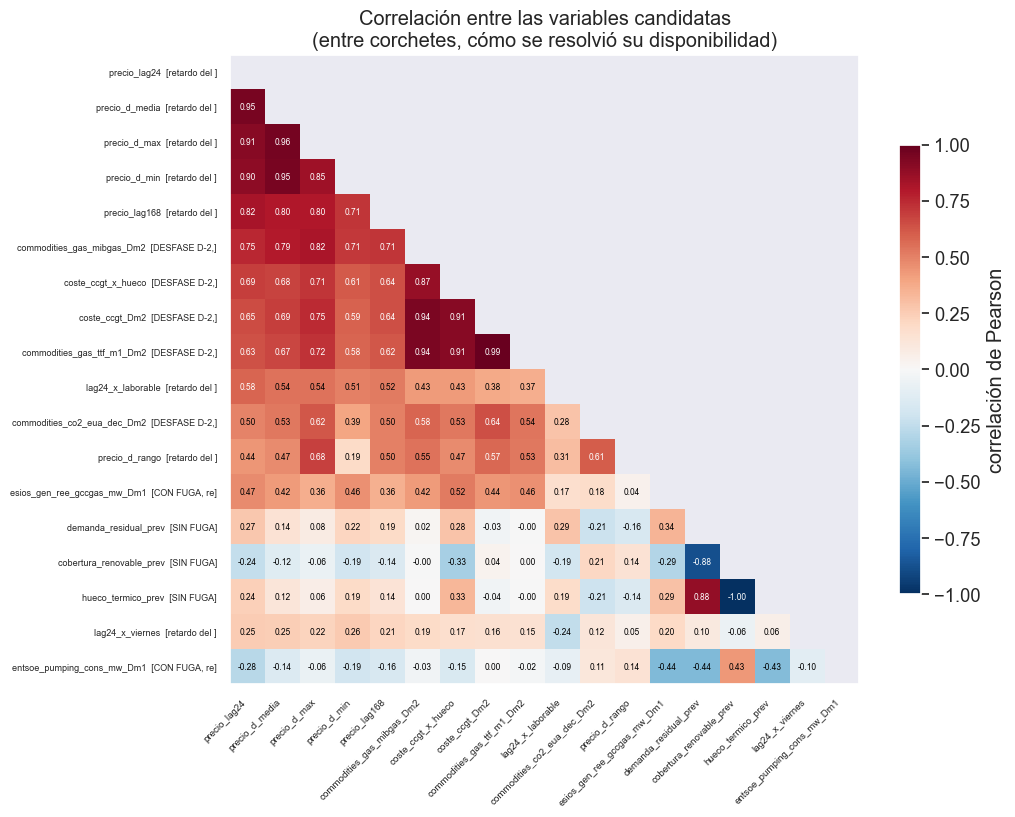

In [30]:
def etiqueta_disp(c):
    if c.endswith("_Dm1") or c in ("temp_Dm1", "hdd_Dm1", "cdd_Dm1"):
        return "CON FUGA, resuelta con retardo"
    if c.endswith("_Dm2") or c.startswith("coste_ccgt"):
        return "DESFASE D-2, resuelto"
    if c.startswith("precio_") or c.startswith("lag24_x_"):
        return "retardo del objetivo"
    return "SIN FUGA"

tr = M["split"] == "train"
principales = [c for c in features
               if M.loc[tr, c].notna().mean() > 0.9 and M.loc[tr, c].std() > 0]
# Se representan las de mayor asociación, que son sobre las que hay que decidir.
r_obj_ = pd.Series({c: abs(M.loc[tr, c].corr(M.loc[tr, "target_price"])) for c in principales})
top_cand = r_obj_.nlargest(18).index.tolist()

Cc = M.loc[tr, top_cand].corr()
fig, ax = plt.subplots(figsize=(10.5, 8.5))
mask_sup = np.triu(np.ones_like(Cc, dtype=bool))
im = ax.imshow(np.where(mask_sup, np.nan, Cc.values), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(Cc)), Cc.columns, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(Cc)), [f"{c}  [{etiqueta_disp(c)[:12]}]" for c in Cc.columns],
              fontsize=6.5)
for i in range(len(Cc)):
    for j in range(i):
        ax.text(j, i, f"{Cc.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(Cc.iloc[i, j]) > 0.55 else "black")
ax.set_title("Correlación entre las variables candidatas\n"
             "(entre corchetes, cómo se resolvió su disponibilidad)")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.7, label="correlación de Pearson")
plt.tight_layout(); plt.show()

In [31]:
m_ = np.triu(np.ones(Cc.shape, dtype=bool), k=1)
pares_c = Cc.where(m_).stack().rename("r").reset_index()
pares_c.columns = ["variable A", "variable B", "r"]
pares_c["|r|"] = pares_c["r"].abs()
altos_c = pares_c[pares_c["|r|"] >= 0.9].sort_values("|r|", ascending=False)

print(f"Pares de candidatas con |r| ≥ 0,9: {len(altos_c)}")
if len(altos_c):
    display(altos_c.round(4).reset_index(drop=True))
    print("\nUna correlación cercana a 1 entre dos variables construidas suele significar que")
    print("una ES la otra por construcción —una suma, una transformación— y no que aporten")
    print("información parecida. El apartado siguiente las agrupa y conserva sólo una de cada")
    print("bloque.")
else:
    print("Ninguna pareja de las más asociadas al objetivo es redundante entre sí.")

Pares de candidatas con |r| ≥ 0,9: 10


,variable A,variable B,r,|r|
0,cobertura_renovable_prev,hueco_termico_prev,-0.9993,0.9993
1,coste_ccgt_Dm2,commodities_gas_ttf_m1_Dm2,0.9913,0.9913
2,precio_d_media,precio_d_max,0.9596,0.9596
3,precio_d_media,precio_d_min,0.9483,0.9483
4,precio_lag24,precio_d_media,0.9465,0.9465
5,commodities_gas_mibgas_Dm2,coste_ccgt_Dm2,0.9442,0.9442
6,commodities_gas_mibgas_Dm2,commodities_gas_ttf_m1_Dm2,0.9399,0.9399
7,coste_ccgt_x_hueco,commodities_gas_ttf_m1_Dm2,0.9089,0.9089
8,precio_lag24,precio_d_max,0.9072,0.9072
9,coste_ccgt_x_hueco,coste_ccgt_Dm2,0.9071,0.9071



Una correlación cercana a 1 entre dos variables construidas suele significar que
una ES la otra por construcción —una suma, una transformación— y no que aporten
información parecida. El apartado siguiente las agrupa y conserva sólo una de cada
bloque.


## 6.2 · Grupos de redundancia

El apartado 8.1 del análisis exploratorio mostró que la eliminación par a par se queda corta: si
tres variables miden lo mismo, recorrer sus pares puede dejar dos en pie según el orden en que se
recorran. Se emplea aquí el mismo procedimiento que allí —agrupamiento jerárquico sobre la
distancia `1 − |r|`, cortado a una altura declarada— que trata cada bloque como una unidad.

De cada grupo se conserva **una sola** variable, y el criterio de elección es su asociación con
el objetivo medida en `train`.

In [32]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

UMBRAL_R = 0.95
completas = [c for c in features
             if M.loc[tr, c].notna().mean() > 0.9 and M.loc[tr, c].std() > 0]
Rm = M.loc[tr, completas].corr().abs().fillna(0)
Dm = 1 - Rm
np.fill_diagonal(Dm.values, 0)
Z = linkage(squareform(Dm.values, checks=False), method="average")
grupos = fcluster(Z, t=1 - UMBRAL_R, criterion="distance")

obj_tr = M.loc[tr, "target_price"]
r_obj = {c: abs(M.loc[tr, c].corr(obj_tr)) for c in completas}

G = pd.DataFrame({"columna": completas, "grupo": grupos})
G["r con objetivo"] = G["columna"].map(r_obj)
multi = G["grupo"].value_counts()
multi = multi[multi > 1].index

eliminadas = set()
print(f"{len(multi)} grupos con más de una variable (|r| >= {UMBRAL_R} dentro del grupo):\n")
for g in multi:
    sub = G[G["grupo"] == g].sort_values("r con objetivo", ascending=False)
    conservada = sub.iloc[0]["columna"]
    fuera_g = sub.iloc[1:]["columna"].tolist()
    eliminadas.update(fuera_g)
    print(f"  Grupo {g}: se conserva '{conservada}' (r = {sub.iloc[0]['r con objetivo']:.4f})")
    for c in fuera_g:
        print(f"      se retira {c:44s} (r = {r_obj[c]:.4f})")

features = [c for c in features if c not in eliminadas]
print(f"\nEliminadas por redundancia: {len(eliminadas)} · quedan {len(features)} variables.")

DEC.anotar("A.7", f"{len(eliminadas)} variables eliminadas por redundancia de grupo", "aplicado",
           f"Agrupamiento jerárquico con |r| >= {UMBRAL_R} en train; de cada grupo se conserva "
           "la más asociada al objetivo. El agrupamiento evita que un recorrido par a par deje "
           "en pie dos miembros del mismo bloque.")

6 grupos con más de una variable (|r| >= 0.95 dentro del grupo):

  Grupo 17: se conserva 'sqrx_eolica_prev' (r = 0.1907)
      se retira eolica_prev                                  (r = 0.1738)
  Grupo 11: se conserva 'solar_prev' (r = 0.1573)
      se retira calc_solar_fv_mw_Dm1                         (r = 0.1477)
  Grupo 30: se conserva 'precio_d_media' (r = 0.8997)
      se retira precio_d_max                                 (r = 0.8848)
  Grupo 18: se conserva 'cobertura_renovable_prev' (r = 0.3246)
      se retira hueco_termico_prev                           (r = 0.3242)
  Grupo 27: se conserva 'coste_ccgt_Dm2' (r = 0.6548)
      se retira commodities_gas_ttf_m1_Dm2                   (r = 0.6363)
  Grupo 35: se conserva 'antiguedad_dias' (r = 0.0897)
      se retira cap_fv_instalada                             (r = 0.0139)

Eliminadas por redundancia: 6 · quedan 51 variables.
  [A.7] aplicado: 6 variables eliminadas por redundancia de grupo


---
# 7 · Importancia y preselección

Se replica el cribado del máster —`Vcramer` y su gráfico— añadiendo la correlación de Pearson y,
para el objetivo categórico, la **d de Cohen** entre horas caras y baratas, que es la que dice si
una variable sirve para la decisión de operación y no sólo para estimar el nivel.

Las tres medidas se calculan sobre `train`.

In [33]:
tr = M["split"] == "train"
Mtr = M[tr]

filas = []
for c in features:
    s_ = Mtr[c]
    if s_.notna().sum() < 500:
        continue
    a = Mtr.loc[Mtr["clase_precio"] == "cara", c].dropna()
    b = Mtr.loc[Mtr["clase_precio"] == "barata", c].dropna()
    d_cohen = np.nan
    if len(a) > 100 and len(b) > 100:
        sp_ = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
        d_cohen = (a.mean() - b.mean()) / sp_ if sp_ else np.nan
    filas.append({"variable": c,
                  "|Pearson|": abs(s_.corr(Mtr["target_price"])),
                  "V de Cramér": v_cramer(s_, Mtr["target_price"]),
                  "|d de Cohen|": abs(d_cohen)})
IMP = pd.DataFrame(filas).set_index("variable")
IMP["rango medio"] = IMP.rank(ascending=False).mean(axis=1)
IMP = IMP.sort_values("rango medio")
display(IMP.head(25).round(4))

,|Pearson|,V de Cramér,|d de Cohen|,rango medio
variable,,,,
precio_lag24,0.9167,0.6491,0.5669,8.3333
precio_lag168,0.8301,0.5581,0.5903,9.3333
demanda_residual_prev,0.3627,0.2353,1.9440,10.0000
cobertura_renovable_prev,0.3246,0.1940,1.4499,11.3333
coste_ccgt_x_hueco,0.7376,0.5458,0.5177,11.6667
entsoe_pumping_cons_mw_Dm1,0.2251,0.1543,1.3957,13.3333
lag24_x_laborable,0.5833,0.4366,0.3291,14.3333
esios_gen_ree_gccgas_mw_Dm1,0.4184,0.2422,0.6538,15.0000
precio_d_media,0.8997,0.5851,0.0000,15.6667


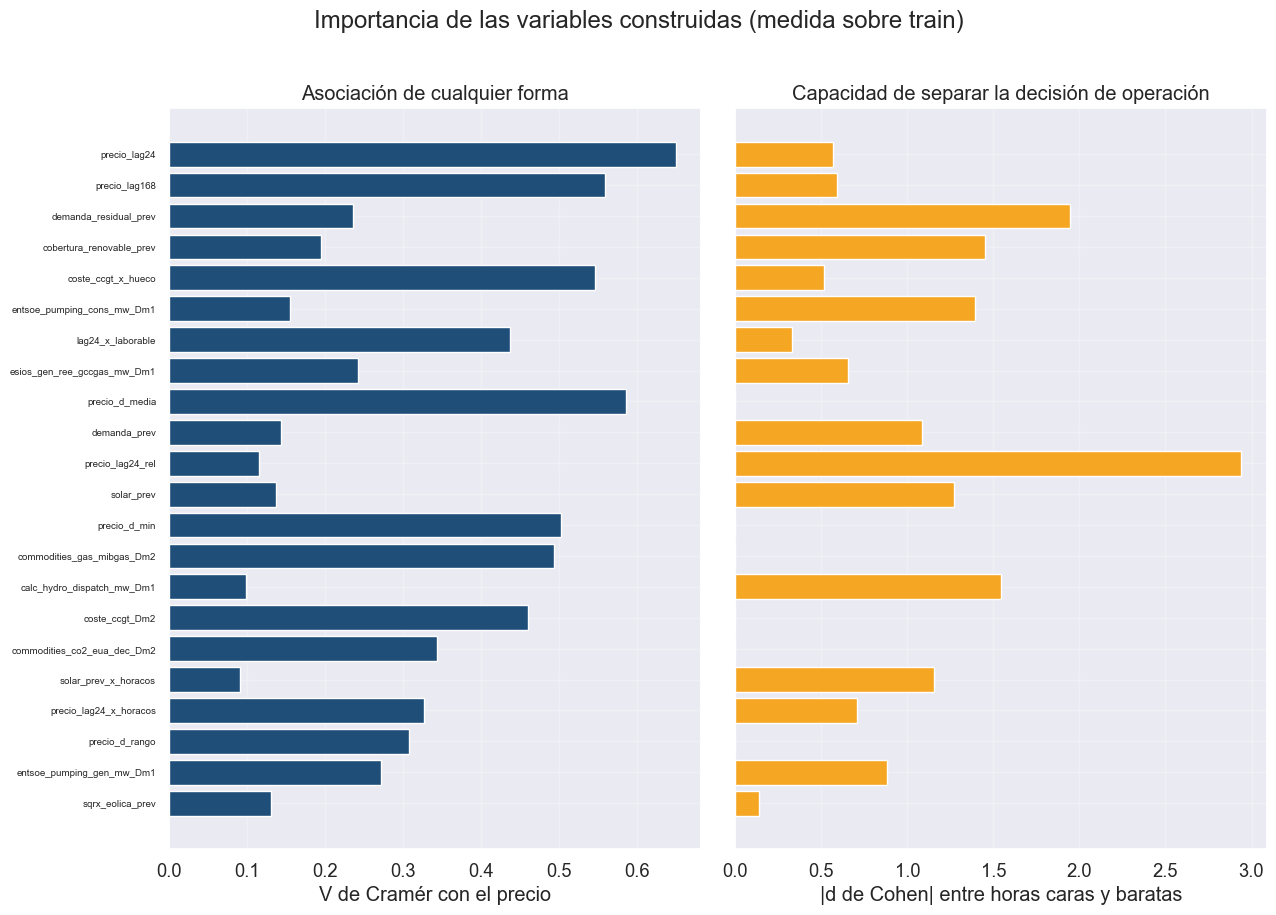

In [34]:
top = IMP.head(22).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 0.34 * len(top) + 1.6), sharey=True)
axes[0].barh(top.index, top["V de Cramér"], color=PALETA["principal"])
axes[0].set_xlabel("V de Cramér con el precio")
axes[0].set_title("Asociación de cualquier forma")
axes[1].barh(top.index, top["|d de Cohen|"], color=PALETA["acento"])
axes[1].set_xlabel("|d de Cohen| entre horas caras y baratas")
axes[1].set_title("Capacidad de separar la decisión de operación")
axes[0].tick_params(axis="y", labelsize=7)
fig.suptitle("Importancia de las variables construidas (medida sobre train)", y=1.01)
plt.tight_layout(); plt.show()

In [35]:
UMBRAL_CRAMER, UMBRAL_PEARSON = 0.05, 0.05
cola = IMP[(IMP["V de Cramér"] < UMBRAL_CRAMER) & (IMP["|Pearson|"] < UMBRAL_PEARSON)]
print(f"Variables por debajo de ambos umbrales ({UMBRAL_CRAMER}): {len(cola)}")
if len(cola):
    display(cola.round(4))

features_final = [c for c in features if c not in cola.index]
print(f"\nPreseleccionadas: {len(features_final)} de {len(features)}")

DEC.anotar("A.8", f"{len(cola)} variables descartadas por asociación despreciable", "aplicado",
           f"V de Cramér < {UMBRAL_CRAMER} y |Pearson| < {UMBRAL_PEARSON} en train. Se descarta "
           "por debajo de AMBOS umbrales, no de uno: una variable no lineal tiene Pearson bajo "
           "y sí aporta.")

Variables por debajo de ambos umbrales (0.05): 1


,|Pearson|,V de Cramér,|d de Cohen|,rango medio
variable,,,,
hora_sin,0.0257,0.0432,0.5161,39.6667



Preseleccionadas: 50 de 51
  [A.8] aplicado: 1 variables descartadas por asociación despreciable


## 7.1 · Cuánta de esa importancia es sólo el calendario

El hallazgo `M.2` del análisis exploratorio advirtió de que buena parte de la asociación de
algunos drivers con el precio desaparece al descontar el ciclo diario y el estacional. La
consecuencia para esta matriz es concreta: la hora y el mes **ya están dentro** de ella, en su
codificación cíclica del apartado 4.6, y son variables sin fuga y sin coste.

Una variable cuya asociación se evapore al controlar por ellas no aporta información nueva: sólo
repite lo que el calendario ya dice. Este apartado la identifica, midiendo la asociación de los
residuos tras descontar los armónicos de hora y mes.

In [36]:
from numpy.linalg import lstsq

CTRL = M[["hora_sin", "hora_cos", "mes_sin", "mes_cos"]]

def residuos(y, X_ctrl, mascara):
    d = pd.concat([y, X_ctrl], axis=1)[mascara].dropna()
    if len(d) < 500:
        return None
    yy = d.iloc[:, 0].to_numpy()
    XX = np.column_stack([np.ones(len(d)), d.iloc[:, 1:].to_numpy()])
    beta, *_ = lstsq(XX, yy, rcond=None)
    return pd.Series(yy - XX @ beta, index=d.index)

res_obj = residuos(M["target_price"], CTRL, tr)
filas = []
for c in features_final:
    if c in CTRL.columns:
        continue
    rb = residuos(M[c], CTRL, tr)
    if rb is None or res_obj is None:
        continue
    comun = res_obj.index.intersection(rb.index)
    if len(comun) < 500:
        continue
    simple = abs(M.loc[tr, c].corr(M.loc[tr, "target_price"]))
    parcial = abs(res_obj.loc[comun].corr(rb.loc[comun]))
    filas.append({"variable": c, "|r| simple": simple, "|r| sin ciclos": parcial,
                  "% que era calendario": (1 - parcial / max(simple, 1e-9)) * 100})
CICLO = pd.DataFrame(filas).set_index("variable").sort_values("% que era calendario",
                                                              ascending=False)
display(CICLO.head(15).round(3))

# Se marca, no se elimina: la variable puede seguir aportando en interacción con otras.
redundantes_cal = CICLO[(CICLO["% que era calendario"] > 90) &
                        (CICLO["|r| sin ciclos"] < 0.05)].index.tolist()
print(f"\nVariables cuya asociación es prácticamente toda calendario: {len(redundantes_cal)}")
for c in redundantes_cal:
    print(f"  {c}")
if redundantes_cal:
    features_final = [c for c in features_final if c not in redundantes_cal]
    print(f"\nRetiradas. Quedan {len(features_final)} variables.")
    DEC.anotar("M.2", f"{len(redundantes_cal)} variables retiradas por repetir el calendario",
               "aplicado",
               "Más del 90 % de su asociación desaparece al descontar los armónicos de hora y "
               "mes, y lo que queda es despreciable. La hora y el mes ya están en la matriz, "
               "sin fuga y sin coste.")
else:
    print("Ninguna variable queda por debajo del umbral: todas aportan algo más que el ciclo.")

,|r| simple,|r| sin ciclos,% que era calendario
variable,,,
eolica_prev_x_horacos,0.071,0.005,92.824
mes,0.120,0.039,67.735
precio_lag24_x_horacos,0.087,0.029,66.869
esios_gen_ree_gnuclear_mw_Dm1,0.058,0.033,43.105
solar_prev_x_horacos,0.137,0.102,25.563
reg_excepcion,0.095,0.076,19.634
antiguedad_dias,0.090,0.072,19.487
precio_lag24_x_horasin,0.063,0.055,11.697
precio_lag24_rel,0.189,0.173,8.861



Variables cuya asociación es prácticamente toda calendario: 1
  eolica_prev_x_horacos

Retiradas. Quedan 49 variables.
  [M.2] aplicado: 1 variables retiradas por repetir el calendario


### La comprobación que da sentido a todo el cuaderno

El EDA midió la mejor correlación absoluta del conjunto —dominada por variables con fuga— y la
mejor correlación utilizable. La distancia entre ambas cuantificaba el coste de la restricción
operativa.

La ingeniería de variables existe precisamente para reducir esa distancia: si las variables
construidas no mejoran sobre las columnas admisibles del bronce en crudo, el trabajo de este
cuaderno no ha aportado nada.

In [37]:
crudas_admisibles = [c for c in admisibles_directas if c in df.columns]
tr_df = df["split"] == "train"
r_crudas = pd.Series({c: abs(df.loc[tr_df, c].corr(df.loc[tr_df, P]))
                      for c in crudas_admisibles}).dropna()

mejor_cruda = r_crudas.max()
mejor_constr = IMP.loc[features_final, "|Pearson|"].max()
print(f"Mejor |r| entre las columnas admisibles del bronce en crudo : {mejor_cruda:.4f}")
print(f"  ({r_crudas.idxmax()})")
print(f"Mejor |r| entre las variables construidas                   : {mejor_constr:.4f}")
print(f"  ({IMP.loc[features_final, '|Pearson|'].idxmax()})")
print(f"\nGanancia de la ingeniería de variables: {mejor_constr - mejor_cruda:+.4f}")

Mejor |r| entre las columnas admisibles del bronce en crudo : 0.7949
  (commodities_gas_mibgas)
Mejor |r| entre las variables construidas                   : 0.9167
  (precio_lag24)

Ganancia de la ingeniería de variables: +0.1218


---
# 8 · Matriz final y registro de decisiones

In [38]:
# `hora` y `dow` no van en el bloque de control: son variables explicativas de pleno derecho
# —el apartado 7 las sitúa entre las más importantes para el objetivo categórico— y viajan con
# el resto de las features. El bloque de control sólo lleva lo que identifica la fila.
COLS_CONTROL = ["ts", "ts_local", "fecha_pred", "fecha_objetivo", "split", "regimen"]
COLS_OBJ = ["target_price", "clase_precio", "es_cara"]
assert not (set(COLS_CONTROL) | set(COLS_OBJ)) & set(features_final), \
    "Una columna de control o de objetivo se ha colado entre las explicativas."
FINAL = M[COLS_CONTROL + COLS_OBJ + features_final].copy()

print(f"Matriz final: {FINAL.shape[0]:,} filas × {FINAL.shape[1]} columnas")
print(f"  {len(COLS_CONTROL)} de control · {len(COLS_OBJ)} objetivos · "
      f"{len(features_final)} variables explicativas\n")
resumen_final = FINAL.groupby("split", sort=False).apply(
    lambda g: pd.Series({"filas": len(g), "desde": g["fecha_objetivo"].min(),
                         "hasta": g["fecha_objetivo"].max(),
                         "% nulos medio": g[features_final].isna().mean().mean() * 100}),
    include_groups=False)
display(resumen_final.loc[["train", "validation", "test"]])

# Las primeras filas no tienen retardo de 168 h: se retiran para no entregar nulos evitables.
sin_retardo = FINAL["precio_lag168"].isna()
print(f"\nFilas sin retardo semanal disponible (arranque de la serie): {int(sin_retardo.sum())}")
FINAL = FINAL[~sin_retardo].copy()
print(f"Matriz entregada: {FINAL.shape[0]:,} filas")

Matriz final: 58,313 filas × 58 columnas
  6 de control · 3 objetivos · 49 variables explicativas



,filas,desde,hasta,% nulos medio
split,,,,
train,43867,2020-01-01 00:00:00+01:00,2025-01-01 00:00:00+01:00,0.187533
validation,8759,2025-01-02 00:00:00+01:00,2026-01-01 00:00:00+01:00,0.168456
test,5687,2026-01-02 00:00:00+01:00,2026-08-26 00:00:00+02:00,0.103351



Filas sin retardo semanal disponible (arranque de la serie): 174
Matriz entregada: 58,139 filas


## 8.1 · Diccionario de variables

In [39]:
def familia_var(c: str) -> str:
    if c.startswith("precio_") or c.startswith("lag24_x_"):
        return "retardos del precio"
    if c.endswith("_Dm1"):
        return "estado real del sistema (D−1)"
    if c.endswith("_Dm2") or c.startswith("coste_ccgt"):
        return "commodities (D−2)"
    if c.endswith("_prev") or "residual" in c or "cobertura" in c:
        return "previsiones y derivadas"
    if "_x_hora" in c:
        return "interacciones con la hora"
    if c.split("_")[0] in ("logx", "expx", "sqrx", "sqrtx", "cuartax", "raiz4"):
        return "transformaciones"
    if c in ("hdd_Dm1", "cdd_Dm1", "temp_Dm1"):
        return "meteorología (D−1)"
    return "calendario y contexto"

DICC = pd.DataFrame({"variable": features_final})
DICC["familia"] = DICC["variable"].map(familia_var)
DICC["disponibilidad"] = np.where(
    DICC["familia"].isin(["estado real del sistema (D−1)", "meteorología (D−1)"]),
    "CON FUGA, resuelta con retardo",
    np.where(DICC["familia"] == "commodities (D−2)", "DESFASE D-2, resuelto", "SIN FUGA"))
DICC = DICC.merge(IMP[["|Pearson|", "V de Cramér"]], left_on="variable",
                  right_index=True, how="left")

display(DICC.groupby(["familia", "disponibilidad"]).agg(
    variables=("variable", "size"), pearson_max=("|Pearson|", "max"),
    cramer_max=("V de Cramér", "max")).round(4))

,,variables,pearson_max,cramer_max
familia,disponibilidad,,,
calendario y contexto,SIN FUGA,12,0.1199,0.4280
commodities (D−2),"DESFASE D-2, resuelto",4,0.7445,0.5458
estado real del sistema (D−1),"CON FUGA, resuelta con retardo",11,0.4184,0.2714
interacciones con la hora,SIN FUGA,3,0.1369,0.0906
previsiones y derivadas,SIN FUGA,7,0.3627,0.2353
retardos del precio,SIN FUGA,12,0.9167,0.6491


In [40]:
SALIDA = cm.RAIZ / "data" / "bronze" / "matriz_ingenieria_variables.parquet"
SALIDA_DIC = cm.RAIZ / "data" / "bronze" / "matriz_ingenieria_variables_diccionario.csv"

guardar = FINAL.copy()
guardar["ts"] = guardar["ts"].dt.tz_convert("UTC").dt.tz_localize(None)
guardar["ts_local"] = guardar["ts_local"].dt.tz_localize(None)
guardar["fecha_pred"] = guardar["fecha_pred"].dt.tz_localize(None)
guardar["fecha_objetivo"] = guardar["fecha_objetivo"].dt.tz_localize(None)
guardar.to_parquet(SALIDA, index=False)
DICC.to_csv(SALIDA_DIC, index=False, encoding="utf-8")

print(f"Matriz      → {SALIDA.relative_to(cm.RAIZ)}  ({SALIDA.stat().st_size / 1e6:.1f} MB)")
print(f"Diccionario → {SALIDA_DIC.relative_to(cm.RAIZ)}")

Matriz      → data\bronze\matriz_ingenieria_variables.parquet  (10.5 MB)
Diccionario → data\bronze\matriz_ingenieria_variables_diccionario.csv


## 8.2 · Registro de decisiones

In [41]:
print(f"{DEC.titulo}\n")
display(DEC.tabla())

REGISTRO DE DECISIONES



,hallazgo,estado,consecuencia
código,,,
A.1,Frontera de disponibilidad aplicada como filtro,aplicado,"25 columnas admitidas sin retardo, 59 sólo con..."
C.1,Ceros espurios de demanda reparados con la seg...,aplicado,Reparar con un segundo camino de ingesta conse...
B.1,fillna(0) sobre la turbinación antes de cualqu...,aplicado,Sólo sobre esta columna: en el resto del conju...
D.1,16 columnas descartadas por hallazgos del EDA,aplicado,"D-02 (agregado inconsistente), D-03 (cambio de..."
P.5,Sesgo de las previsiones corregido con la medi...,aplicado,Se conservan ambas versiones (`_corr` y origin...
A.2,"Diagnóstico de atípicos ejecutado, tratamiento...",razonado,En este dominio el valor extremo es el fenómen...
A.3,Imputación por interpolación temporal en lugar...,aplicado,Límite de 3 horas. La media del máster introdu...
P.1,"Retardos del precio construidos: 24 h, 168 h y...",aplicado,Ambos retardos entran; el EDA mostró que su ut...
P.6,Temperatura sustituida por grados-día de frío ...,aplicado,La relación en U del EDA no la capta un términ...


---
## Cierre

**Lo que entrega este cuaderno.** Una matriz de modelado en la que cada columna estaba disponible
a las 12:00 del día D, cada corrección responde a un hallazgo demostrado en el análisis
exploratorio, y cada decisión —umbral, imputación, transformación, cribado— se tomó mirando
únicamente el subconjunto de entrenamiento.

**Lo que deliberadamente no hace.**

*No selecciona el modelo.* La preselección del apartado 7 es un cribado por asociación, no una
selección de variables. Y esa selección **no se hará con el `stepwise` por AIC o BIC** que enseña
la asignatura: el apartado 0.2 razona por qué no transfiere a este
problema —el procedimiento supone observaciones independientes, y con la autocorrelación medida
en el apartado 3.6 los criterios de información quedan sesgados hacia modelos con variables de
más—. La selección se hará con validación temporal o regularización, midiendo la aportación de
cada variable sobre el tramo de validación.

*No resuelve las dos incidencias abiertas.* El rendimiento imposible del bombeo (`F.1`) y el
coeficiente de utilización superior al 100 % (`F.2`) siguen sin explicación. Las columnas
implicadas —`cap_disp_*` y el par de bombeo— quedan fuera de la matriz por esa razón, y no por
falta de asociación con el objetivo.

*No mejora la limitación meteorológica.* La matriz entrena con reanálisis porque no existe
histórico de previsiones. Todo resultado que se apoye en las columnas meteorológicas sigue siendo
una **cota superior optimista**, tal como estableció el apartado 5.2 del análisis exploratorio.

**La referencia que hay que batir.** La regla horaria fija, ahora medida fuera de muestra en el
apartado 5.1, captura un porcentaje conocido del techo de arbitraje. Ésa, y no el error absoluto
medio, es la cifra frente a la que se juzga si el modelo aporta algo.